## SHAP-Based Transfer Failure Diagnosis

This notebook reports the authoritative v2 SHAP and `δj` results from the versioned local artifact layout. It keeps the RF-first subject-level validation step while using the corrected local paths for SHAP arrays, fitted models, and result JSONs.


### Cell 1 — Imports, Configuration, and Data Loading

Loads the authoritative v2 SHAP summary, cross-condition results, and within-condition results from the versioned local directories. Constructs the core `(n_features, 6, 7)` arrays indexing `δj` values by `[feature, direction, classifier]`.


In [21]:
import io
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import shap
from IPython.display import Image as IPyImage
from IPython.display import display
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy import stats

sys.path.insert(0, '../src')
from features import ALL_FEATURE_COLS

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

RESULTS_DIR = Path('../experiments/results/v2')
FEATURE_COLS = ALL_FEATURE_COLS
SHAP_DIR = Path('../experiments/shap/v2')
MODELS_DIR = Path('../experiments/models/v2')
FIGURES_PDF = Path('../report/figures/v2/pdf')
FIGURES_PNG = Path('../report/figures/v2/png')
FIGURES_PDF.mkdir(parents=True, exist_ok=True)
FIGURES_PNG.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / 'shap_results_v2.json') as f:
    shap_res = json.load(f)
with open(RESULTS_DIR / 'cross_condition_results_v2.json') as f:
    cc = json.load(f)
with open(RESULTS_DIR / 'pd_results_v2.json') as f:
    pd_res = json.load(f)
with open(RESULTS_DIR / 'hd_results_v2.json') as f:
    hd_res = json.load(f)
with open(RESULTS_DIR / 'als_results_v2.json') as f:
    als_res = json.load(f)

DIRECTIONS = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABELS = ['PD→HD', 'HD→PD', 'PD→ALS', 'ALS→PD', 'HD→ALS', 'ALS→HD']
CLF_NAMES = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']
BEST_CLF = {
    'pd': max(CLF_NAMES, key=lambda c: pd_res['classifiers'][c]['f1_macro']),
    'hd': max(CLF_NAMES, key=lambda c: hd_res['classifiers'][c]['f1_macro']),
    'als': max(CLF_NAMES, key=lambda c: als_res['classifiers'][c]['f1_macro']),
}
SOURCE_FROM_DIR = {
    'pd_to_hd': 'pd', 'hd_to_pd': 'hd', 'pd_to_als': 'pd',
    'als_to_pd': 'als', 'hd_to_als': 'hd', 'als_to_hd': 'als',
}
WITHIN_F1_PER_CLF = {
    'pd': {c: pd_res['classifiers'][c]['f1_macro'] for c in CLF_NAMES},
    'hd': {c: hd_res['classifiers'][c]['f1_macro'] for c in CLF_NAMES},
    'als': {c: als_res['classifiers'][c]['f1_macro'] for c in CLF_NAMES},
}

n_feats = len(FEATURE_COLS)
n_dirs = len(DIRECTIONS)
n_clfs = len(CLF_NAMES)

delta_j_matrix = np.zeros((n_feats, n_dirs, n_clfs))
delta_j_norm_matrix = np.zeros((n_feats, n_dirs, n_clfs))
mean_abs_within_mat = np.zeros((n_feats, n_dirs, n_clfs))
mean_abs_cross_mat = np.zeros((n_feats, n_dirs, n_clfs))

for di, d in enumerate(DIRECTIONS):
    for ci, c in enumerate(CLF_NAMES):
        delta_j_matrix[:, di, ci] = shap_res[d][c]['delta_j']
        delta_j_norm_matrix[:, di, ci] = shap_res[d][c]['delta_j_normalized']
        mean_abs_within_mat[:, di, ci] = shap_res[d][c]['mean_abs_within']
        mean_abs_cross_mat[:, di, ci] = shap_res[d][c]['mean_abs_cross']

cv_swing_idx = FEATURE_COLS.index('cv_swing')
cv_stride_idx = FEATURE_COLS.index('cv_stride')
rf_cv_swing = {label: float(val) for label, val in zip(DIR_LABELS, delta_j_matrix[cv_swing_idx, :, 0].round(4))}
rf_cv_stride = {label: float(val) for label, val in zip(DIR_LABELS, delta_j_matrix[cv_stride_idx, :, 0].round(4))}
print(f'delta_j_matrix shape: {delta_j_matrix.shape}  (features × directions × classifiers)')
print(f'Feature count: {len(FEATURE_COLS)}  ->  {FEATURE_COLS}')
print(f'RF cv_swing δj values: {rf_cv_swing}')
print(f'RF cv_stride δj values: {rf_cv_stride}')


delta_j_matrix shape: (17, 6, 7)  (features × directions × classifiers)
Feature count: 17  ->  ['left_stride_s', 'right_stride_s', 'left_swing_s', 'right_swing_s', 'left_swing_pct', 'right_swing_pct', 'left_stance_s', 'right_stance_s', 'left_stance_pct', 'right_stance_pct', 'double_support_s', 'double_support_pct', 'asymmetry_index', 'cv_stride', 'stride_asymmetry_signed', 'cv_swing', 'dfa_alpha_stride']
RF cv_swing δj values: {'PD→HD': 0.032, 'HD→PD': 0.0289, 'PD→ALS': 0.0612, 'ALS→PD': 0.0569, 'HD→ALS': 0.0109, 'ALS→HD': 0.0797}
RF cv_stride δj values: {'PD→HD': 0.0193, 'HD→PD': 0.0195, 'PD→ALS': 0.016, 'ALS→PD': 0.0096, 'HD→ALS': 0.0227, 'ALS→HD': 0.0067}


### Cell 2 — δj Heatmap (Primary Publication Figure)

Two side-by-side heatmaps showing the transfer-failure signature across all **17** features and 6 directions:

- **Panel A (raw δj, RF only):** The absolute shift in mean |SHAP value| for RF. Features are sorted by mean δj across directions so the most transfer-sensitive features appear at the top. In the authoritative v2 run, **`cv_swing` is the dominant RF transfer-shift feature overall**: it ranks first in 5 of the 6 directions (`pd_to_hd`, `hd_to_pd`, `pd_to_als`, `als_to_pd`, `als_to_hd`). `cv_stride` remains important but takes the RF rank-1 spot only in `hd_to_als`. `dfa_alpha_stride` is most visible in the PD-source RF directions, where its δj is `0.0305` for `pd_to_hd` and `0.0416` for `pd_to_als`.

- **Panel B (normalised δj, mean across 7 classifiers):** Normalising by within-condition importance converts absolute shifts to fractional changes, making cross-classifier comparison valid. Averaged across all directions and classifiers, the leading features are `cv_swing` (`mean δj = 0.0415`), `cv_stride` (`0.0172`), and `dfa_alpha_stride` (`0.0122`). The mean across classifiers tests whether the shift is a consensus property of all algorithm families or specific to one.

**What to look for:** `cv_swing` dominating the top of the heatmap, `cv_stride` acting as a secondary variability feature, `dfa_alpha_stride` showing a directional pattern rather than a uniform effect, and stance/asymmetry features becoming more condition-specific in ALS-source directions.


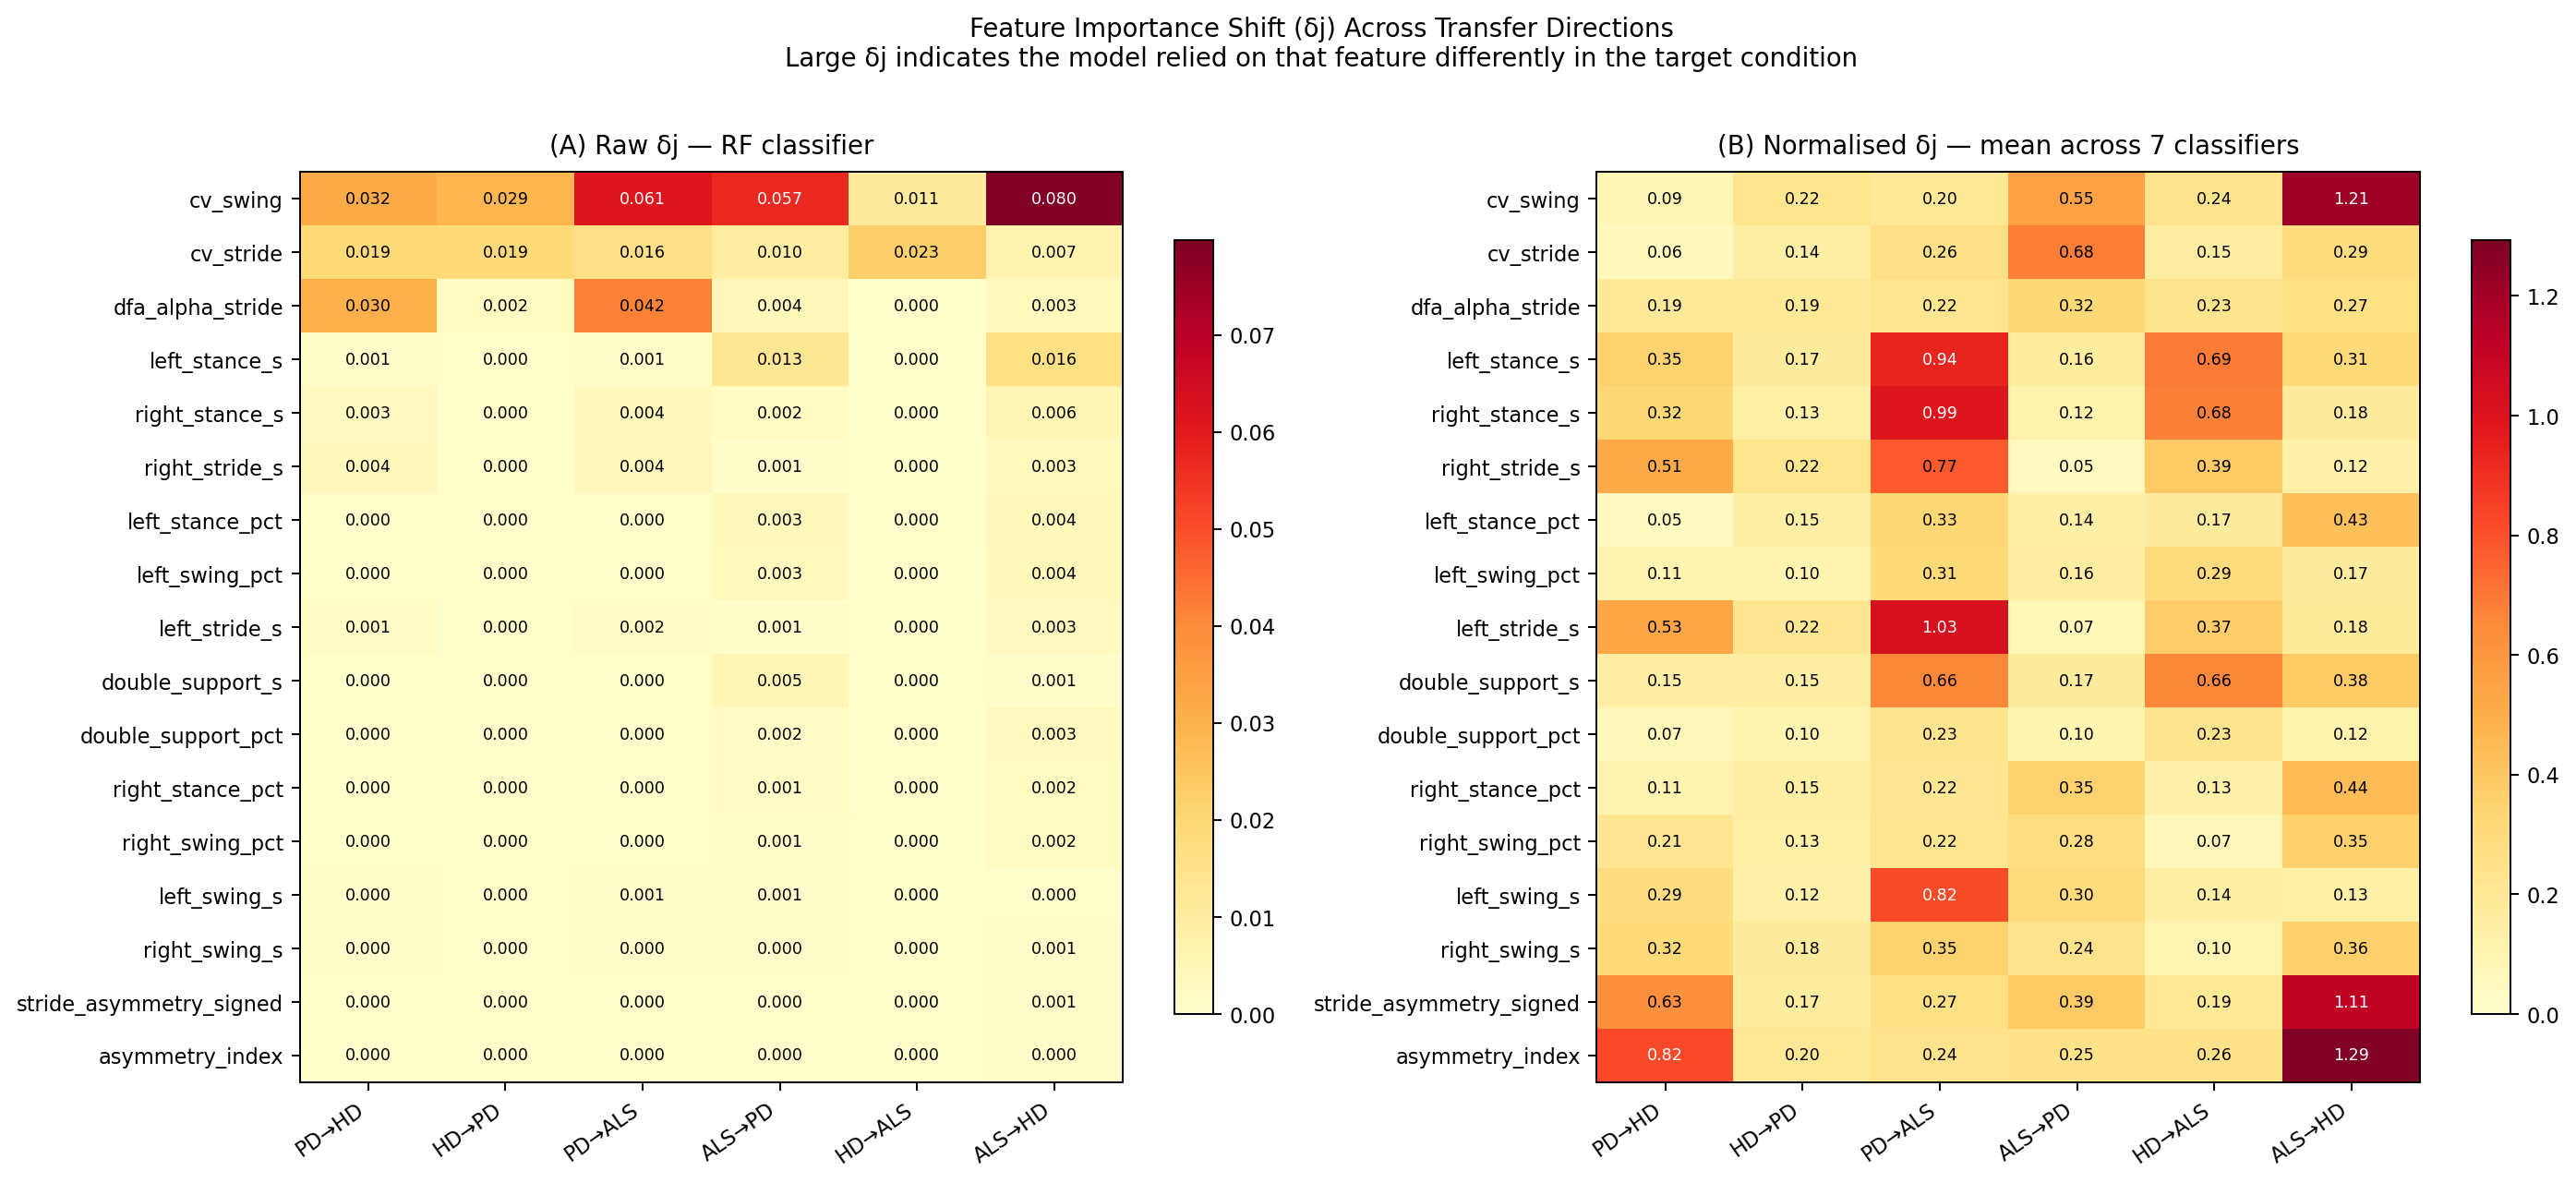

Saved delta_j_heatmap.pdf / .png


In [22]:
# RF raw δj: shape (14, 6)
dj_rf = delta_j_matrix[:, :, 0]          # classifier index 0 = rf
# Cross-classifier mean normalised δj: shape (14, 6)
dj_norm_mean = delta_j_norm_matrix.mean(axis=2)   # mean over classifiers

# Sort rows by mean δj (RF) across all 6 directions so the most shifting features appear at top
row_order = np.argsort(dj_rf.mean(axis=1))[::-1]
feat_labels_sorted = [FEATURE_COLS[i] for i in row_order]
dj_rf_sorted       = dj_rf[row_order, :]
dj_norm_sorted     = dj_norm_mean[row_order, :]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, fmt in zip(
    axes,
    [dj_rf_sorted, dj_norm_sorted],
    ['(A) Raw δj — RF classifier', '(B) Normalised δj — mean across 7 classifiers'],
    ['{:.3f}', '{:.2f}'],
):
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=0)
    ax.set_xticks(range(n_dirs))
    ax.set_xticklabels(DIR_LABELS, rotation=35, ha='right')
    ax.set_yticks(range(n_feats))
    ax.set_yticklabels(feat_labels_sorted)
    ax.set_title(title, pad=8)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for i in range(n_feats):
        for j in range(n_dirs):
            val = data[i, j]
            txt_color = 'white' if val > 0.6 * data.max() else 'black'
            ax.text(j, i, fmt.format(val), ha='center', va='center',
                    fontsize=7, color=txt_color)

fig.suptitle(
    'Feature Importance Shift (δj) Across Transfer Directions\n'
    'Large δj indicates the model relied on that feature differently in the target condition',
    fontsize=11, y=1.01,
)
fig.tight_layout()

fig.savefig(FIGURES_PDF / f'delta_j_heatmap.pdf')
fig.savefig(FIGURES_PNG / f'delta_j_heatmap.png')
plt.show()
print('Saved delta_j_heatmap.pdf / .png')

### Cell 2b — `dfa_alpha_stride` Directional Asymmetry

This figure isolates the transfer-shift profile of `dfa_alpha_stride`, which is the most biologically distinctive v2 feature and one of the clearest directional findings in the SHAP analysis.

For the RF classifier, the authoritative v2 `delta_j` values are **highest in the PD-source transfers** (`pd_to_hd = 0.0305`, `pd_to_als = 0.0416`), modest in the ALS-source transfers (`als_to_pd = 0.0043`, `als_to_hd = 0.0031`), and essentially near-zero in the HD-source RF directions (`hd_to_pd = 0.0019`, `hd_to_als = 0.0002`). So the pattern is not “uniformly HD-source dominant”; it is directionally asymmetric.

**What to look for:** strong PD-source bars, near-flat HD-source RF bars, and a much more selective shift profile than the broad variability features (`cv_swing`, `cv_stride`).


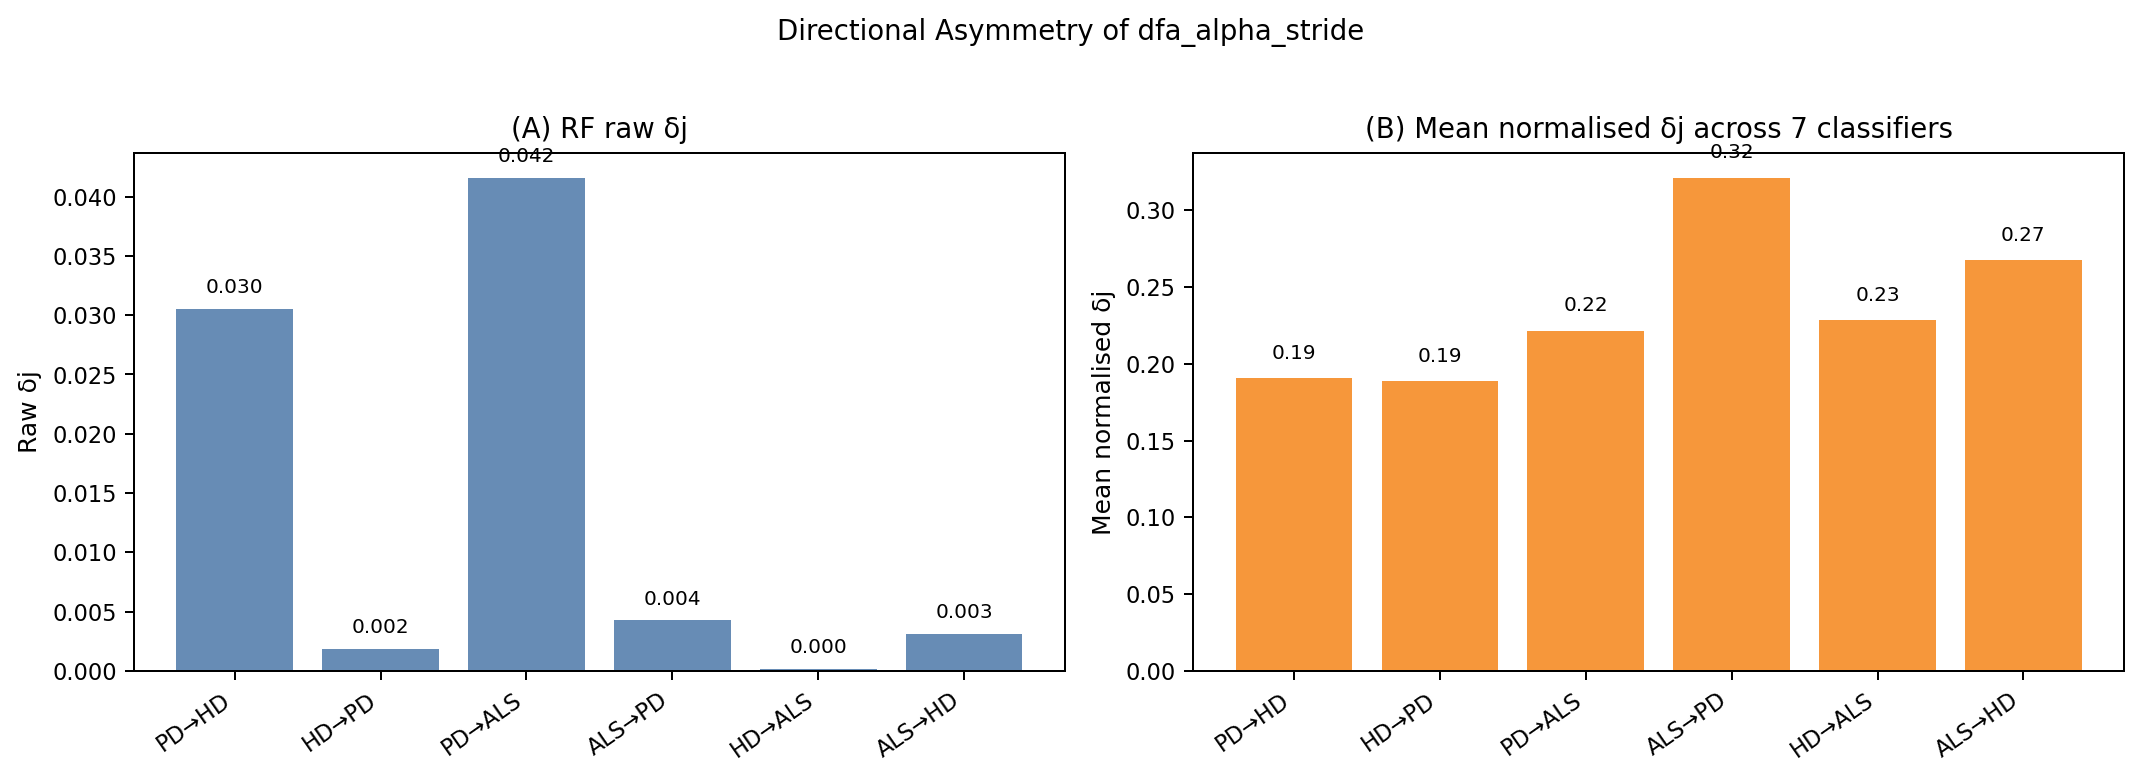

Saved: dfa_alpha_stride_directionality.pdf / .png


In [23]:
dfa_idx = FEATURE_COLS.index('dfa_alpha_stride')
rf_idx = CLF_NAMES.index('rf')

dfa_rf = delta_j_matrix[dfa_idx, :, rf_idx]
dfa_norm_mean = delta_j_norm_matrix[dfa_idx, :, :].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
axes[0].bar(np.arange(n_dirs), dfa_rf, color='#4C78A8', alpha=0.85)
axes[0].set_xticks(range(n_dirs))
axes[0].set_xticklabels(DIR_LABELS, rotation=35, ha='right')
axes[0].set_ylabel('Raw δj')
axes[0].set_title('(A) RF raw δj')
for i, v in enumerate(dfa_rf):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

axes[1].bar(np.arange(n_dirs), dfa_norm_mean, color='#F58518', alpha=0.85)
axes[1].set_xticks(range(n_dirs))
axes[1].set_xticklabels(DIR_LABELS, rotation=35, ha='right')
axes[1].set_ylabel('Mean normalised δj')
axes[1].set_title('(B) Mean normalised δj across 7 classifiers')
for i, v in enumerate(dfa_norm_mean):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Directional Asymmetry of dfa_alpha_stride', fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'dfa_alpha_stride_directionality.pdf')
fig.savefig(FIGURES_PNG / 'dfa_alpha_stride_directionality.png')
plt.show()
print('Saved: dfa_alpha_stride_directionality.pdf / .png')


### Cell 3 — Cross-Classifier δj Consistency (Spearman Correlation)

For each of the 6 transfer directions, computes a **7×7 Spearman rank correlation matrix** of the **17-dimensional** δj vectors across classifiers. Entry (i, j) answers: “Do classifier i and classifier j agree on which features shift most for this direction?”

**Scientific significance:** If classifiers show high mutual correlation (dark green cells), the δj pattern is likely reflecting a shared biomechanical shift rather than an algorithm-specific quirk. If correlations are low, the failure mechanism is more classifier-specific, which is itself informative about how different model families respond to distribution shift.

**What to look for:** whether tree-based classifiers (RF, DT, XGBoost, LightGBM) cluster together more strongly than the distance/kernel methods, and whether any directions produce broad cross-family agreement versus fragmented rank patterns.


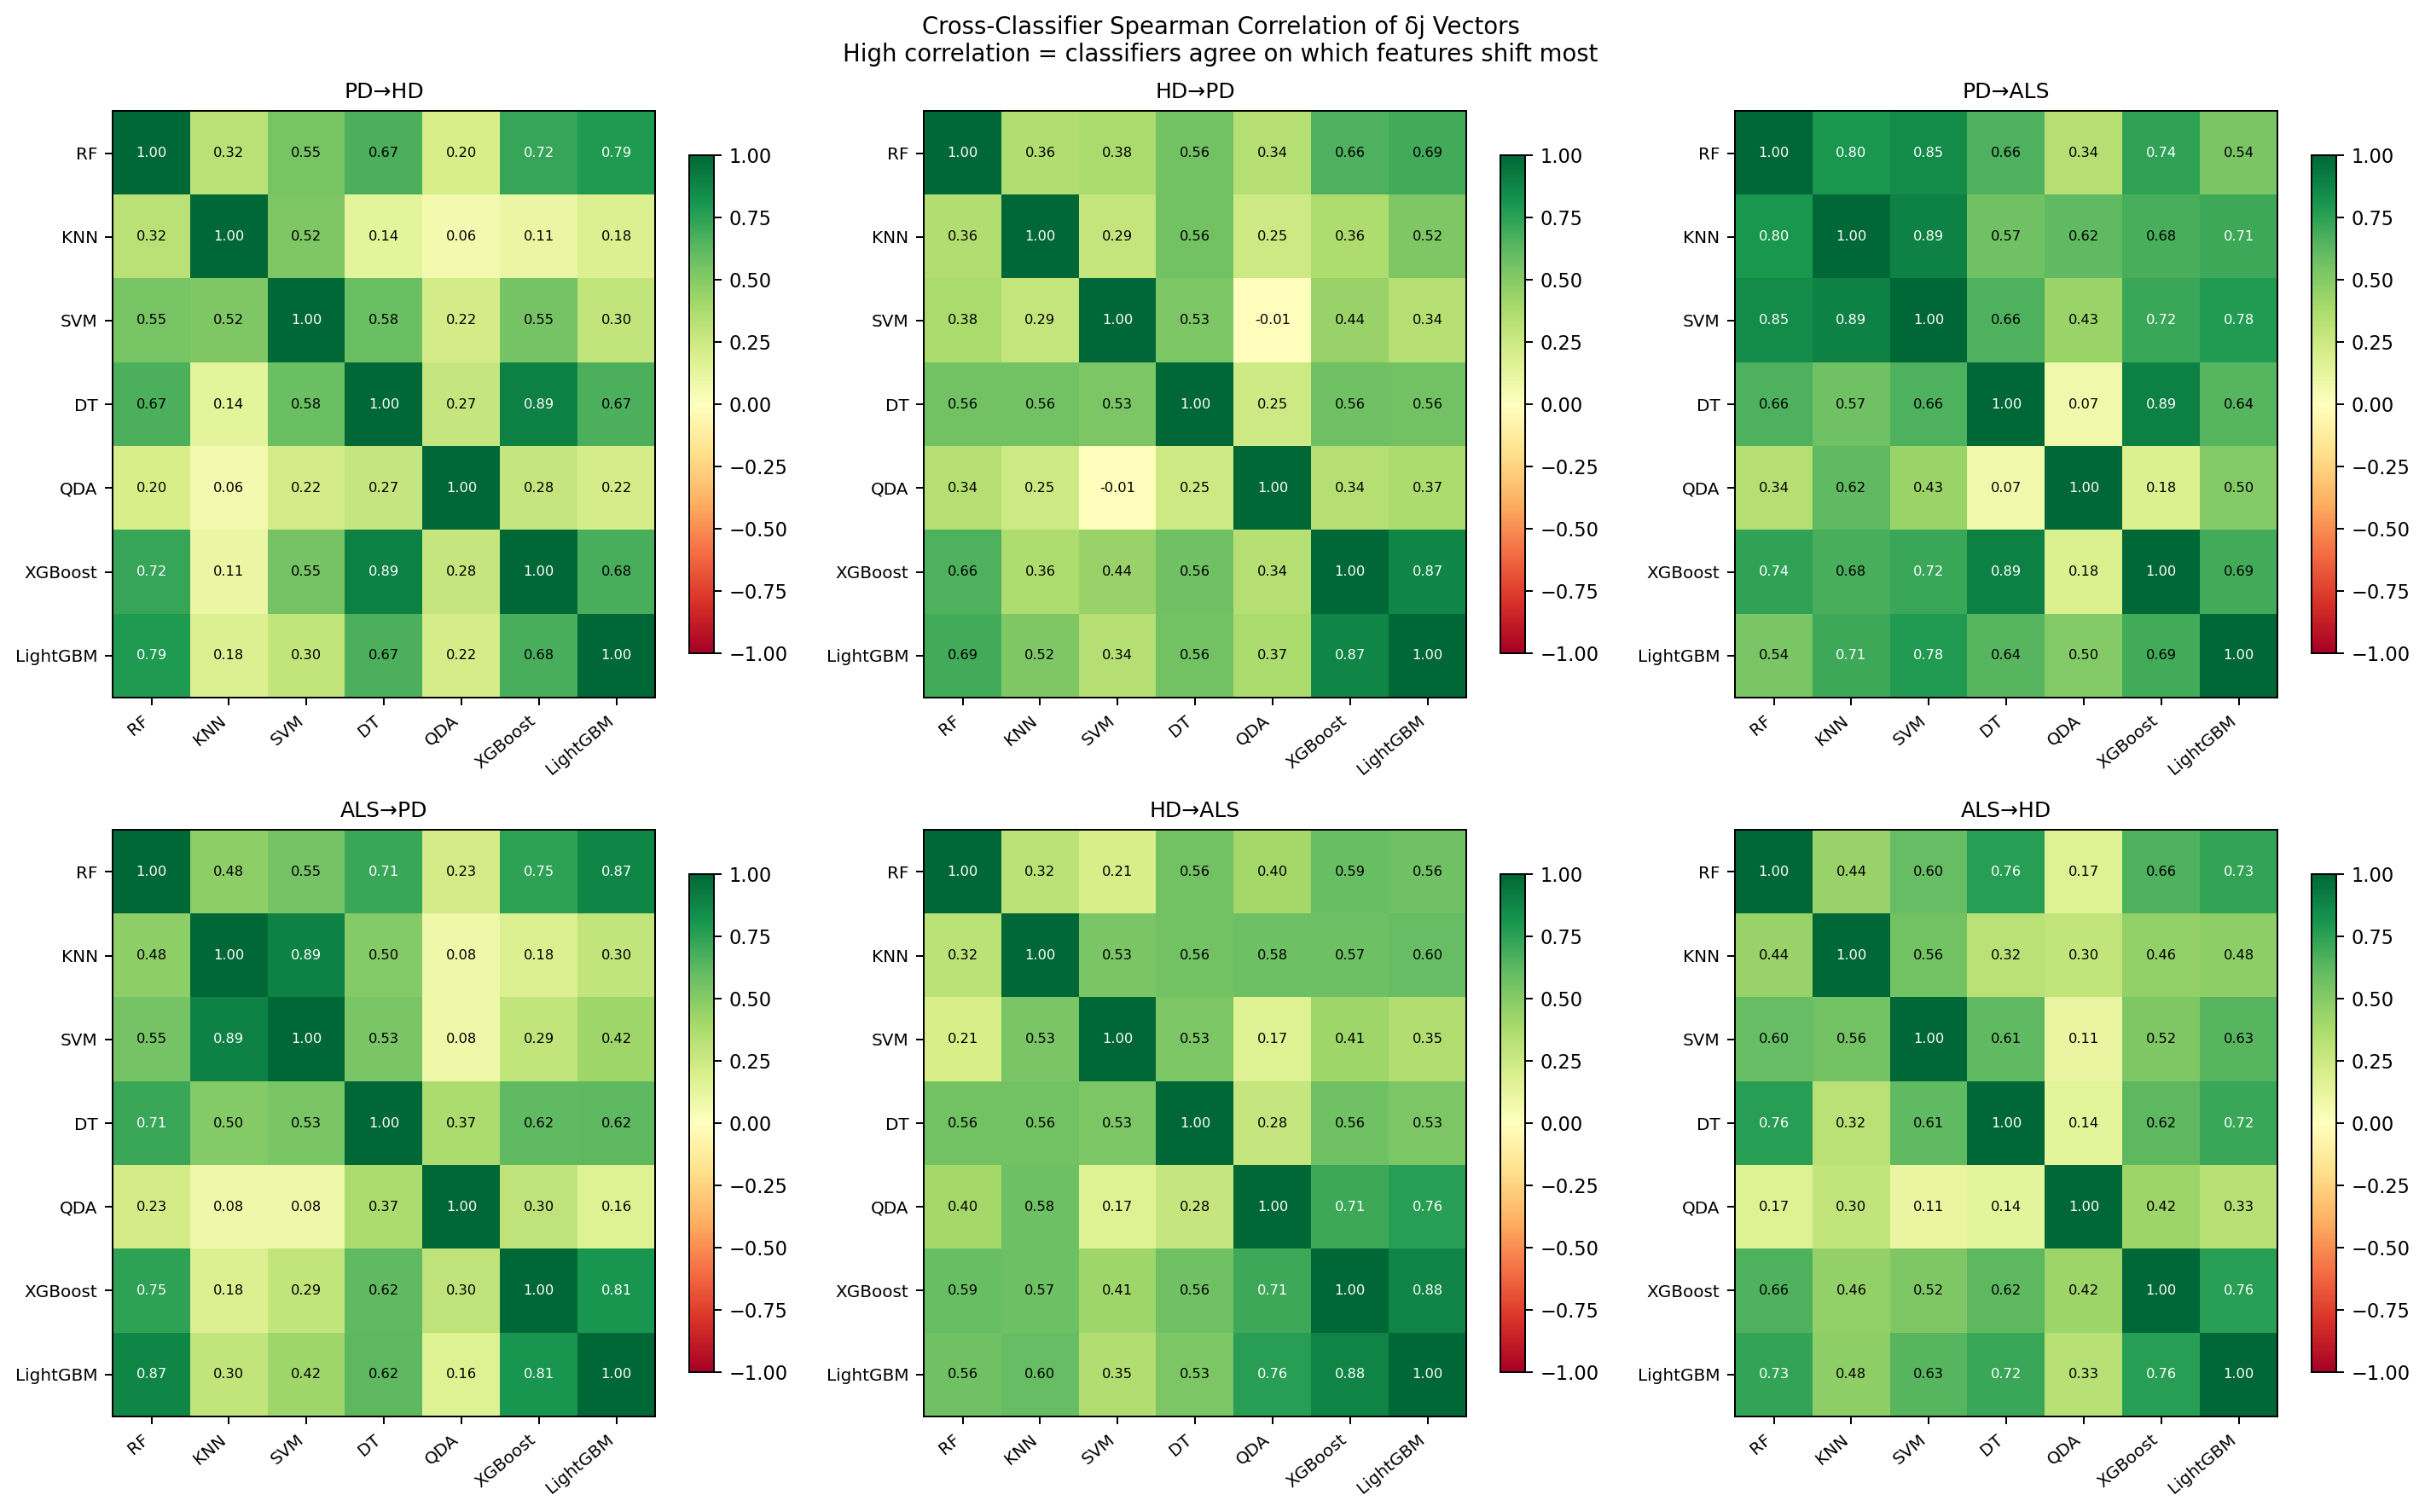

Saved delta_j_spearman.pdf / .png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.ravel()

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    ax = axes_flat[di]
    dj_block = delta_j_matrix[:, di, :]   # (14, 7)
    corr_mat = np.zeros((n_clfs, n_clfs))
    for ci in range(n_clfs):
        for cj in range(n_clfs):
            rho, _ = stats.spearmanr(dj_block[:, ci], dj_block[:, cj])
            corr_mat[ci, cj] = rho

    im = ax.imshow(corr_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_clfs))
    ax.set_xticklabels(CLF_LABELS, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(n_clfs))
    ax.set_yticklabels(CLF_LABELS, fontsize=8)
    ax.set_title(dl, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for ci in range(n_clfs):
        for cj in range(n_clfs):
            ax.text(cj, ci, f'{corr_mat[ci, cj]:.2f}', ha='center', va='center',
                    fontsize=6.5,
                    color='white' if abs(corr_mat[ci, cj]) > 0.7 else 'black')

fig.suptitle(
    'Cross-Classifier Spearman Correlation of δj Vectors\n'
    'High correlation = classifiers agree on which features shift most',
    fontsize=11,
)
fig.tight_layout()

fig.savefig(FIGURES_PDF / f'delta_j_spearman.pdf')
fig.savefig(FIGURES_PNG / f'delta_j_spearman.png')
plt.show()
print('Saved delta_j_spearman.pdf / .png')

### Cell 4 — SHAP Mean Absolute Importance: Within vs Cross (RF Only)

Six paired horizontal bar charts — one per transfer direction — showing RF’s **mean absolute SHAP value** for each feature in two settings:

- **Blue (within-condition):** How much the RF model relied on each feature when classifying strides from the source condition against Control Group A during LOSO-CV.
- **Red (cross-condition):** How much the same fitted model relied on each feature when applied zero-shot to the target condition.

Features are sorted by within-condition importance (ascending, so the most important feature is at the top of each chart). The **gap between blue and red** is the visual representation of δj.

**What to look for:** `cv_swing` is the largest or near-largest within-condition RF feature for the PD-source and HD-source directions, and it usually also shows the largest blue-to-red shift. `cv_stride` remains a secondary variability feature and becomes the largest RF gap only for `hd_to_als`. For ALS-source directions, `left_stance_s` rises to the top within-condition RF importance, with `cv_swing` and `cv_stride` just behind it. Features where the red bar exceeds the blue bar represent increased reliance cross-condition.


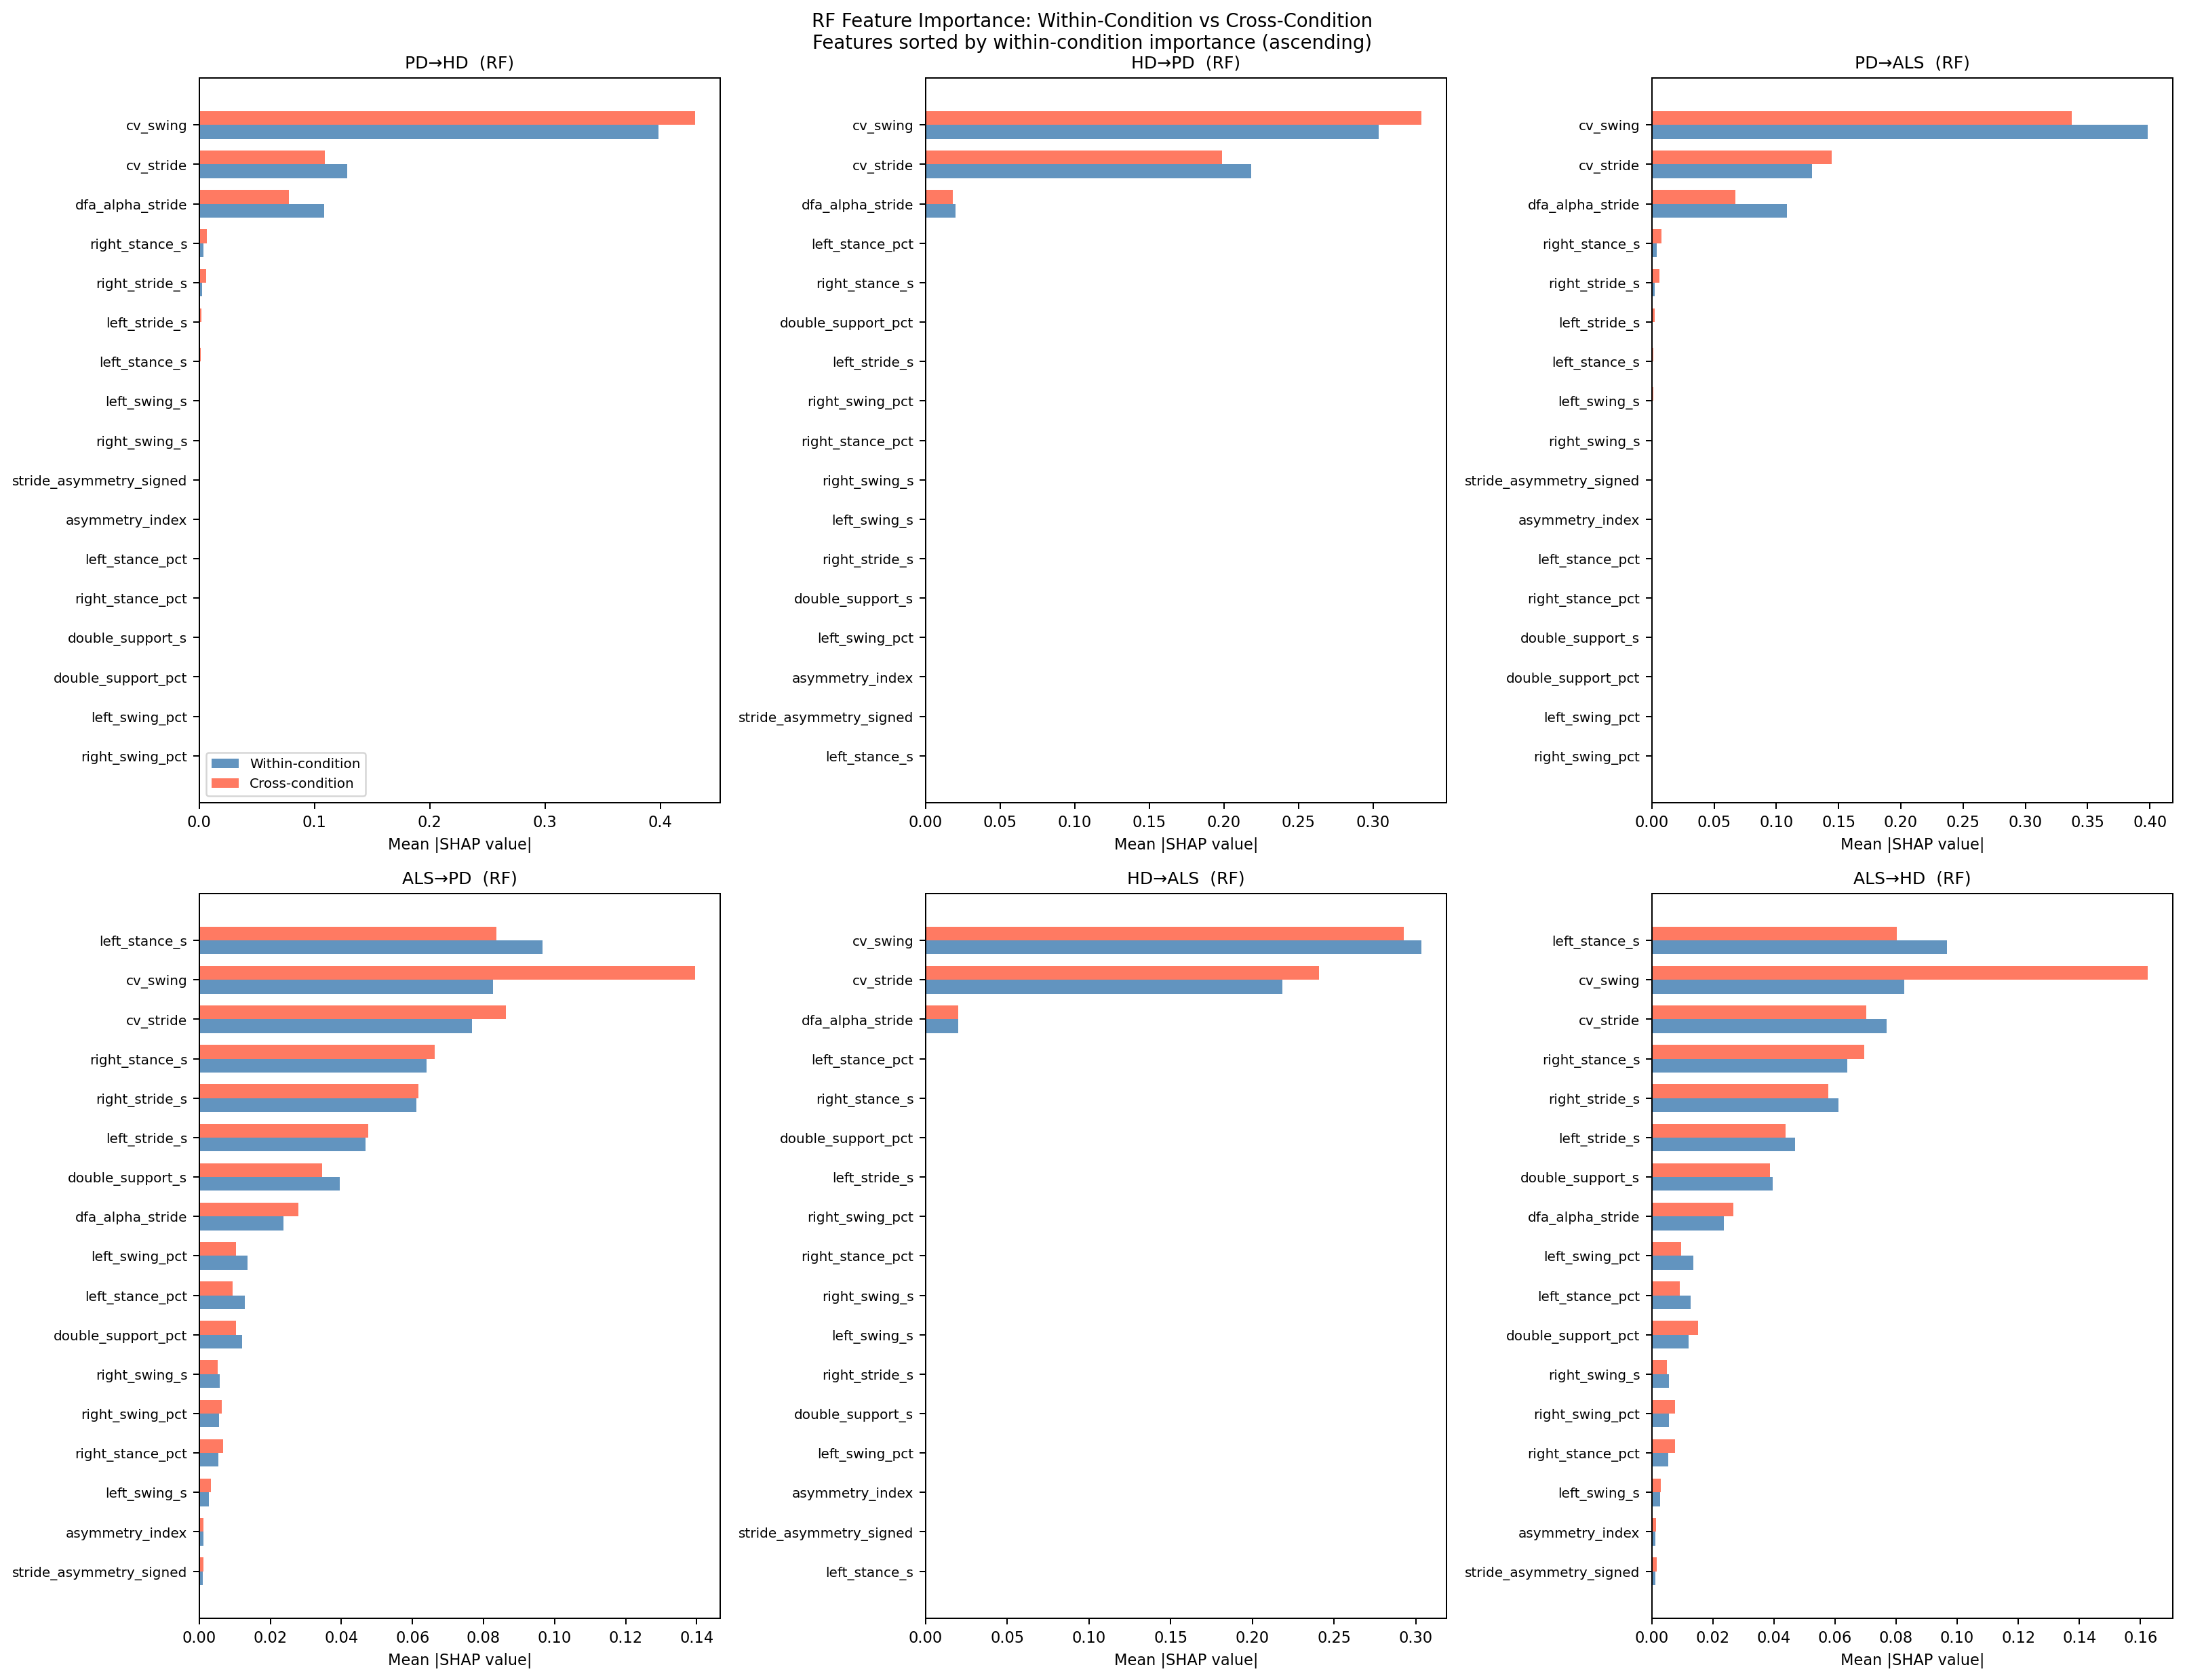

Saved shap_importance_within_vs_cross.pdf / .png


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes_flat = axes.ravel()

rf_ci = CLF_NAMES.index('rf')   # 0

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    ax = axes_flat[di]
    within = mean_abs_within_mat[:, di, rf_ci]
    cross  = mean_abs_cross_mat[:, di, rf_ci]

    # Sort ascending so most important feature appears at the top in barh
    order = np.argsort(within)
    feat_names = [FEATURE_COLS[i] for i in order]
    w_sorted   = within[order]
    c_sorted   = cross[order]

    y = np.arange(n_feats)
    height = 0.35
    ax.barh(y - height/2, w_sorted, height, label='Within-condition', color='steelblue', alpha=0.85)
    ax.barh(y + height/2, c_sorted, height, label='Cross-condition',  color='tomato',    alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(feat_names, fontsize=8)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.set_title(f'{dl}  (RF)', fontsize=10)
    if di == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    'RF Feature Importance: Within-Condition vs Cross-Condition\n'
    'Features sorted by within-condition importance (ascending)',
    fontsize=11,
)
fig.tight_layout()

fig.savefig(FIGURES_PDF / f'shap_importance_within_vs_cross.pdf')
fig.savefig(FIGURES_PNG / f'shap_importance_within_vs_cross.png')
plt.show()
print('Saved shap_importance_within_vs_cross.pdf / .png')

### Cell 5 — Top δj Features Summary Table

A ranked table of the **top-3 transfer-failure features per direction** for the RF classifier, showing both raw δj (absolute shift) and normalised δj (fractional shift relative to within-condition importance).

The table confirms the current authoritative pattern: **`cv_swing` is RF rank-1 in 5 of the 6 directions**, while `cv_stride` is RF rank-1 only for `hd_to_als`. `dfa_alpha_stride` enters the RF top-3 in 4 of the 6 directions and is especially prominent for PD-source transfer. `left_stance_s` appears in the ALS-source directions.

The matplotlib version uses per-cell background colors computed by mapping each cell’s value through the `YlOrRd` colormap with luminance-based text color selection, matching the pandas `background_gradient` display.


,Direction,Rank,Feature,δj (raw),δj (norm)
0,PD→HD,1,cv_swing,0.0320,0.0802
1,PD→HD,2,dfa_alpha_stride,0.0305,0.2812
2,PD→HD,3,cv_stride,0.0193,0.1504
3,HD→PD,1,cv_swing,0.0289,0.0953
4,HD→PD,2,cv_stride,0.0195,0.0893
5,HD→PD,3,dfa_alpha_stride,0.0019,0.0937
6,PD→ALS,1,cv_swing,0.0612,0.1535
7,PD→ALS,2,dfa_alpha_stride,0.0416,0.3834
8,PD→ALS,3,cv_stride,0.0160,0.1243
9,ALS→PD,1,cv_swing,0.0569,0.6875


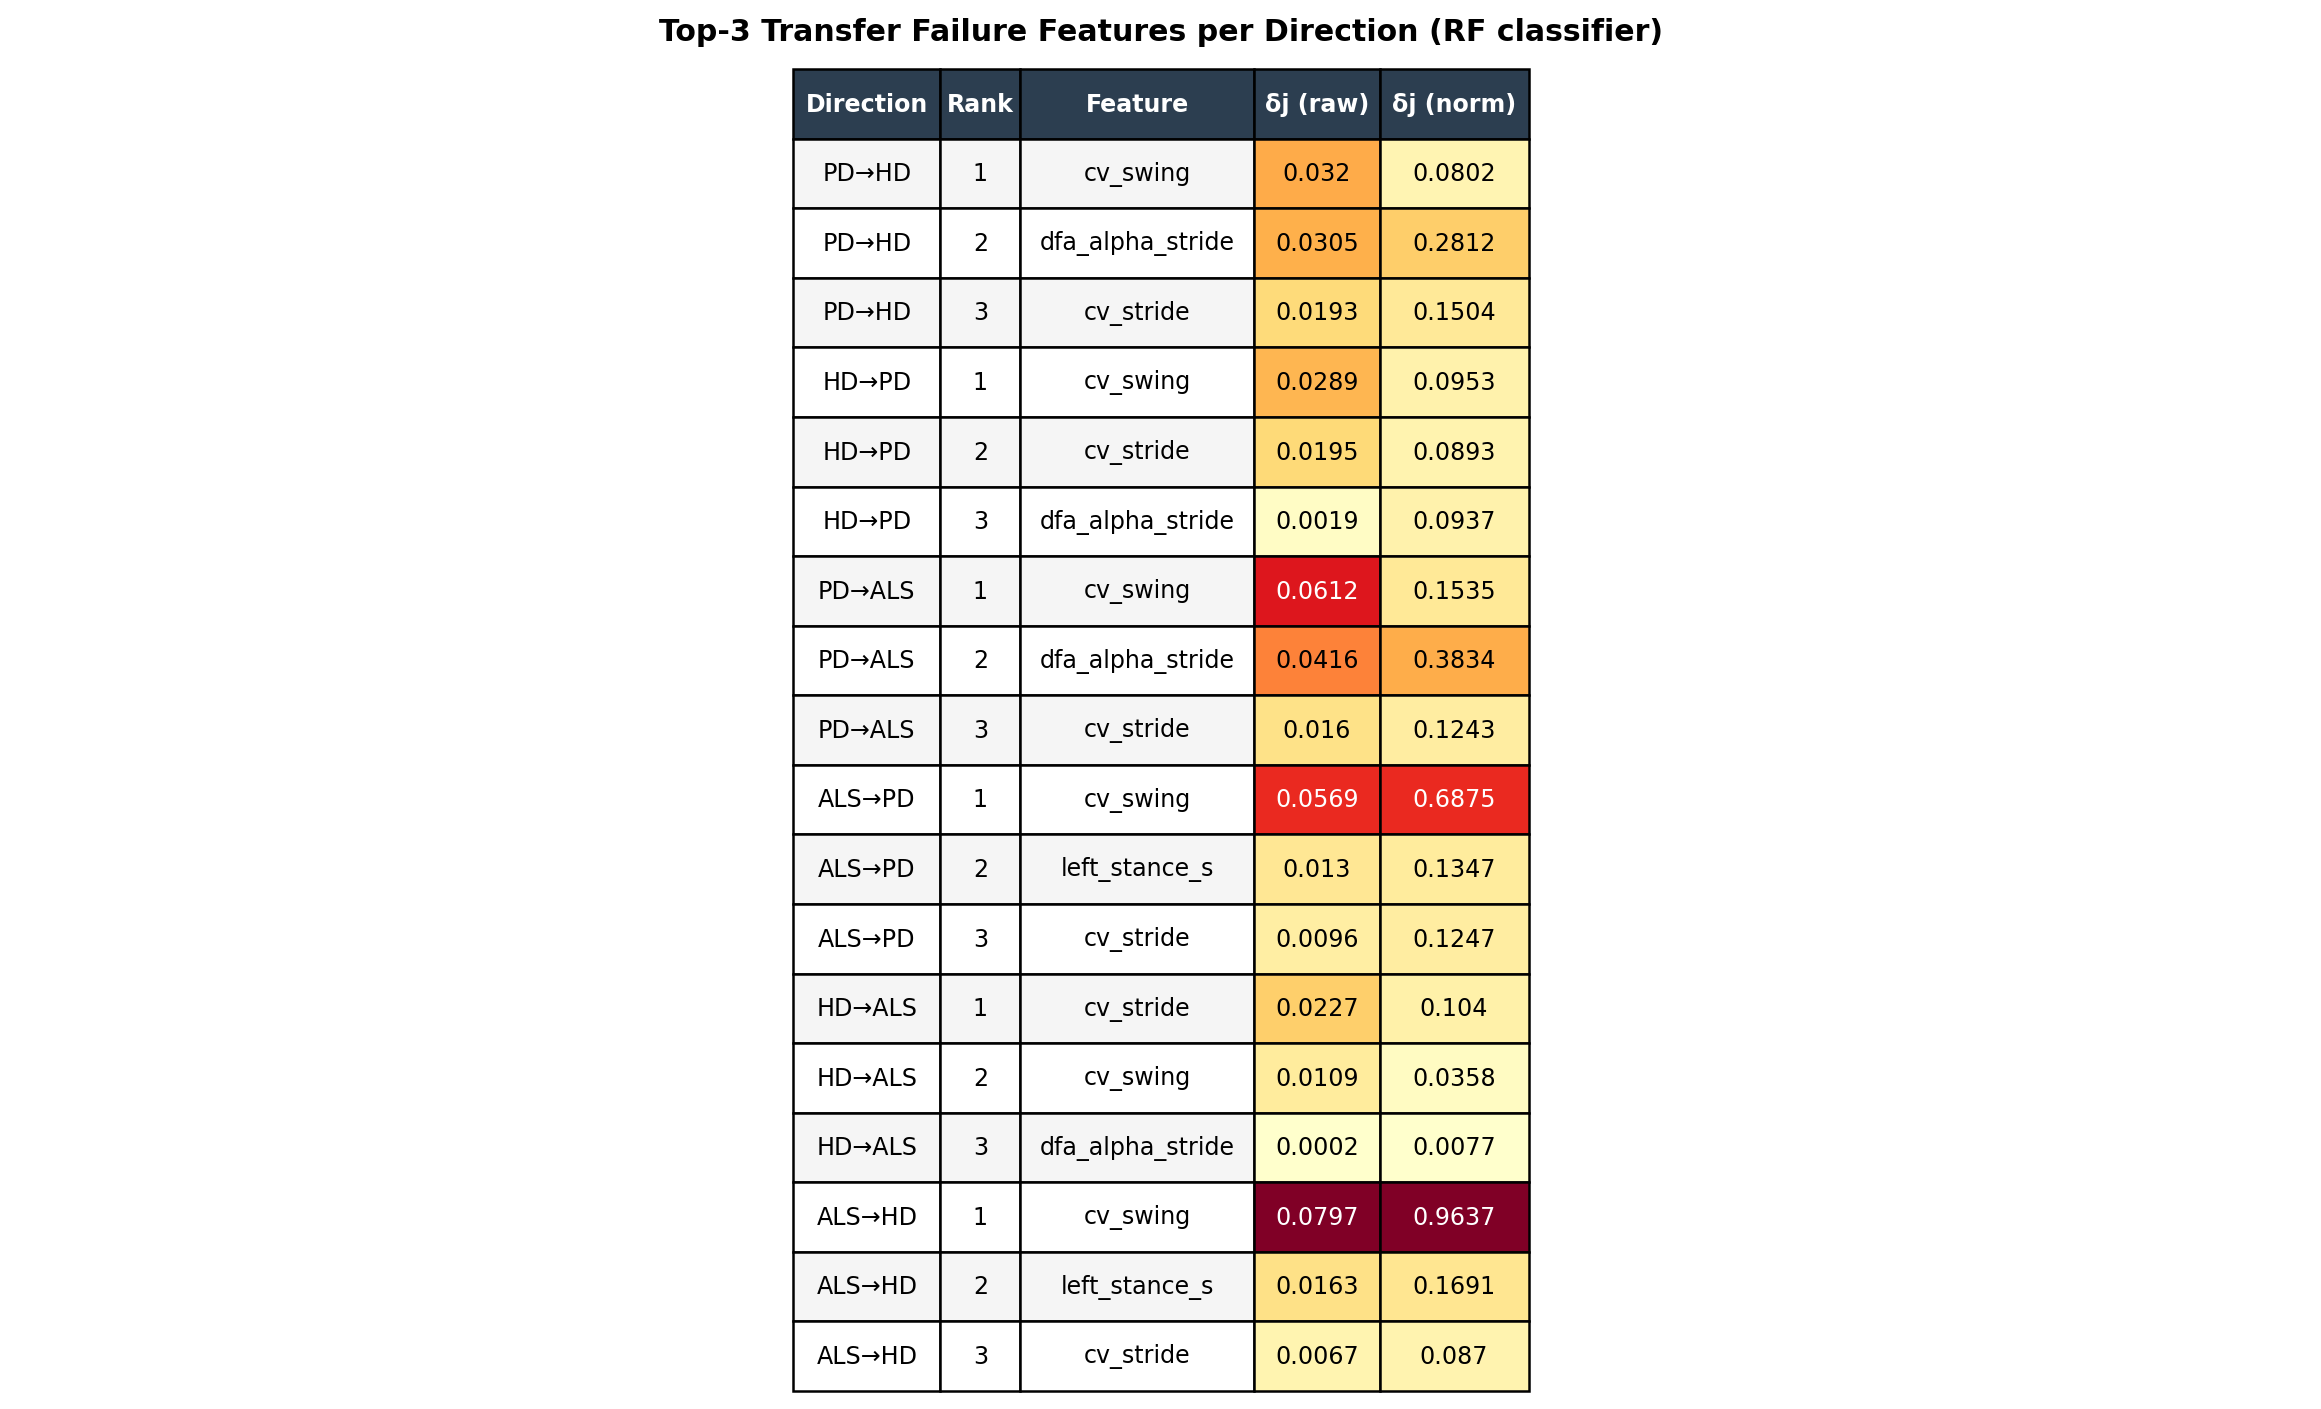

Saved top_delta_j_table.pdf / .png


In [26]:
rf_ci = CLF_NAMES.index('rf')

rows = []
for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    dj_raw  = delta_j_matrix[:, di, rf_ci]
    dj_norm = delta_j_norm_matrix[:, di, rf_ci]
    top3 = np.argsort(dj_raw)[::-1][:3]
    for rank, idx in enumerate(top3, 1):
        rows.append({
            'Direction': dl,
            'Rank':      rank,
            'Feature':   FEATURE_COLS[idx],
            'δj (raw)':  round(float(dj_raw[idx]), 4),
            'δj (norm)': round(float(dj_norm[idx]), 4),
        })

df_top3 = pd.DataFrame(rows)

# HTML display with pandas gradient
display(
    df_top3.style
    .set_caption('Top-3 Transfer Failure Features per Direction (RF classifier)')
    .background_gradient(subset=['δj (raw)', 'δj (norm)'], cmap='YlOrRd')
    .format({'δj (raw)': '{:.4f}', 'δj (norm)': '{:.4f}'})
)

# Matplotlib version — per-cell color intensity on the two δj columns
col_labels = list(df_top3.columns)
cell_text  = df_top3.astype(str).values.tolist()

dj_raw_vals  = df_top3['δj (raw)'].values.astype(float)
dj_norm_vals = df_top3['δj (norm)'].values.astype(float)
norm_raw  = Normalize(vmin=dj_raw_vals.min(),  vmax=dj_raw_vals.max())
norm_norm = Normalize(vmin=dj_norm_vals.min(), vmax=dj_norm_vals.max())
cmap_tbl  = cm.get_cmap('YlOrRd')

# Pre-compute per-cell colour lists so we can pass cellColours to table()
n_rows = len(cell_text)
n_cols = len(col_labels)
cell_colors = []
for data_row in range(n_rows):
    row_colors = []
    for col in range(n_cols):
        if col == 3:   # δj (raw)
            rgba = cmap_tbl(norm_raw(dj_raw_vals[data_row]))
            row_colors.append(rgba)
        elif col == 4:   # δj (norm)
            rgba = cmap_tbl(norm_norm(dj_norm_vals[data_row]))
            row_colors.append(rgba)
        elif data_row % 2 == 0:
            row_colors.append('#f5f5f5')
        else:
            row_colors.append('#ffffff')
    cell_colors.append(row_colors)

fig_t, ax_t = plt.subplots(figsize=(13, 8))
ax_t.axis('off')

tbl = ax_t.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.auto_set_column_width(col=list(range(n_cols)))
tbl.scale(1, 2.2)

# Header row: dark background, white bold text
for j in range(n_cols):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].get_text().set_color('white')
    tbl[0, j].get_text().set_fontweight('bold')

# Set text colour for δj cells based on luminance of their background
for data_row in range(n_rows):
    for col in [3, 4]:
        rgba = cell_colors[data_row][col]
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        tbl[data_row + 1, col].get_text().set_color(
            'white' if luminance < 0.5 else 'black'
        )

fig_t.text(0.5, 0.97,
           'Top-3 Transfer Failure Features per Direction (RF classifier)',
           ha='center', va='top', fontsize=12, fontweight='bold')
fig_t.tight_layout(rect=[0, 0, 1, 0.95])

fig_t.savefig(FIGURES_PDF / f'top_delta_j_table.pdf')
fig_t.savefig(FIGURES_PNG / f'top_delta_j_table.png')
plt.show()
plt.close(fig_t)
print('Saved top_delta_j_table.pdf / .png')


### Cell 6 — Emerged Features Analysis

**Emerged features** are features where `mean(|φj_within|) < 1e-3` — the model assigned near-zero importance to that feature in the source condition — but `δj > 0`, meaning its importance shifted when applied cross-condition. The model began relying on a feature it previously ignored.

In the stored authoritative v2 output, emerged features are **not** confined to XGBoost and LightGBM. The most frequent emerged feature is `stride_asymmetry_signed` (12 direction/classifier pairs), followed by `double_support_s` and `asymmetry_index` (10 each). RF contributes many emerged pairs as well, so the effect is broader than a gradient-boosting-only phenomenon.

**What to look for:** `stride_asymmetry_signed` leading the emergence counts, a sizable RF contribution, and multiple timing/asymmetry features appearing as cross-condition-only activations when the model encounters a shifted gait distribution.


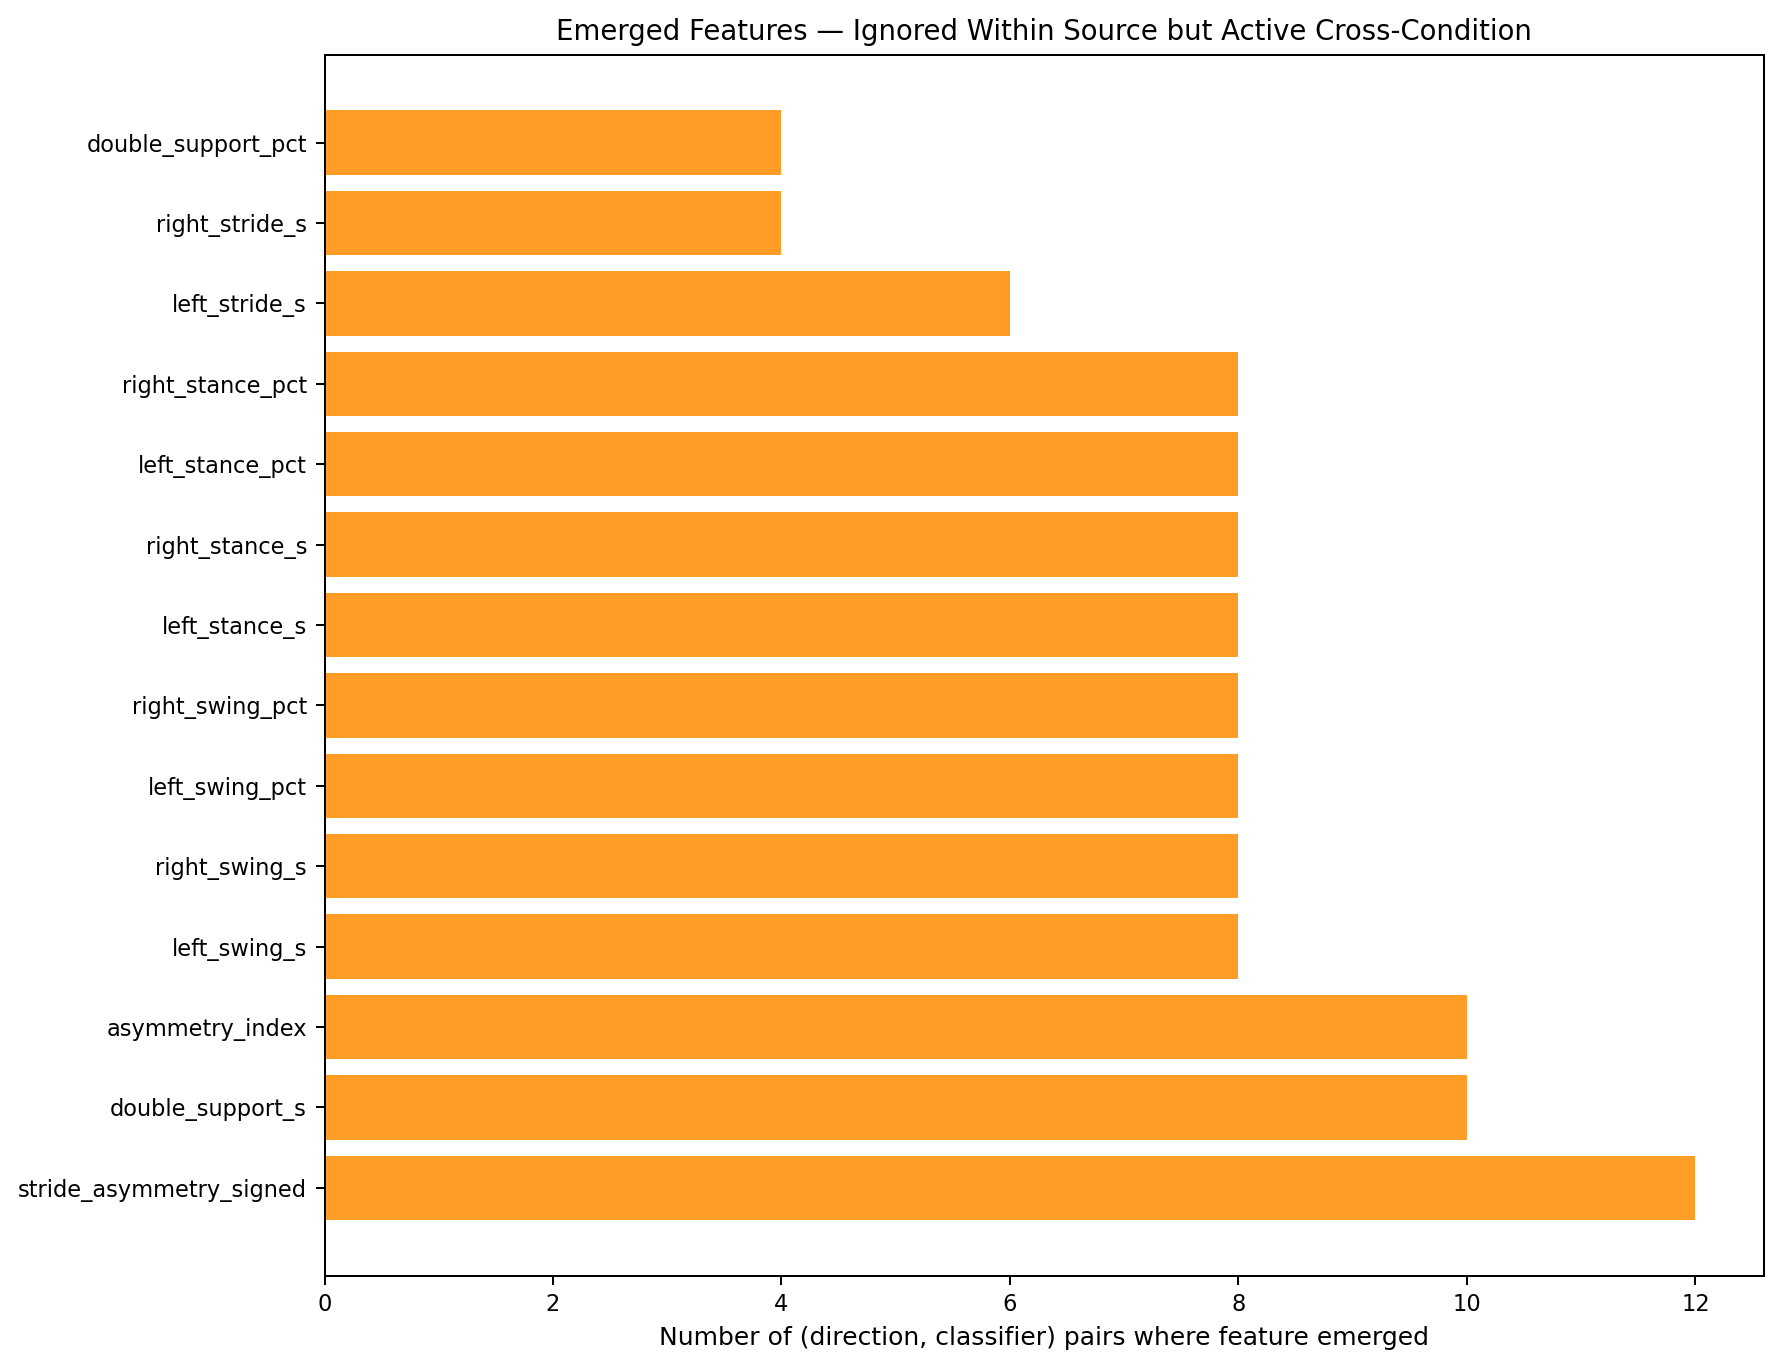

Saved emerged_features.pdf / .png

Emergence detail (feature: [direction/classifier pairs]):
  stride_asymmetry_signed: ['PD→HD/RF', 'PD→HD/LightGBM', 'HD→PD/RF', 'HD→PD/QDA', 'HD→PD/LightGBM', 'PD→ALS/RF', 'PD→ALS/LightGBM', 'ALS→PD/QDA', 'HD→ALS/RF', 'HD→ALS/QDA', 'HD→ALS/LightGBM', 'ALS→HD/QDA']
  double_support_s: ['PD→HD/RF', 'PD→HD/LightGBM', 'HD→PD/RF', 'HD→PD/XGBoost', 'HD→PD/LightGBM', 'PD→ALS/RF', 'PD→ALS/LightGBM', 'HD→ALS/RF', 'HD→ALS/XGBoost', 'HD→ALS/LightGBM']
  asymmetry_index: ['PD→HD/RF', 'PD→HD/LightGBM', 'HD→PD/RF', 'HD→PD/XGBoost', 'HD→PD/LightGBM', 'PD→ALS/RF', 'PD→ALS/LightGBM', 'HD→ALS/RF', 'HD→ALS/XGBoost', 'HD→ALS/LightGBM']
  left_swing_s: ['PD→HD/RF', 'PD→HD/LightGBM', 'HD→PD/RF', 'HD→PD/XGBoost', 'PD→ALS/RF', 'PD→ALS/LightGBM', 'HD→ALS/RF', 'HD→ALS/XGBoost']
  right_swing_s: ['PD→HD/RF', 'PD→HD/LightGBM', 'HD→PD/RF', 'PD→ALS/RF', 'PD→ALS/LightGBM', 'ALS→PD/DT', 'HD→ALS/RF', 'ALS→HD/DT']
  left_swing_pct: ['PD→HD/RF', 'HD→PD/RF', 'HD→PD/XGBoost', 'PD→ALS/RF'

In [27]:
emerge_count = np.zeros(n_feats, dtype=int)
emerge_details = {feat: [] for feat in FEATURE_COLS}

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    for ci, (clf, cl) in enumerate(zip(CLF_NAMES, CLF_LABELS)):
        for fidx in shap_res[d][clf]['emerged_features']:
            emerge_count[fidx] += 1
            emerge_details[FEATURE_COLS[fidx]].append(f'{dl}/{cl}')

if emerge_count.sum() == 0:
    print('No emerged features across all 42 (direction, classifier) pairs.')
    print('All features had mean(|φj_within|) ≥ 1e-3 in every source condition.')
else:
    active_feats = [(FEATURE_COLS[i], emerge_count[i])
                    for i in range(n_feats) if emerge_count[i] > 0]
    active_feats.sort(key=lambda x: x[1], reverse=True)

    feat_names_plot = [x[0] for x in active_feats]
    counts_plot     = [x[1] for x in active_feats]

    fig, ax = plt.subplots(figsize=(10, max(3, len(feat_names_plot) * 0.55)))
    y = np.arange(len(feat_names_plot))
    ax.barh(y, counts_plot, color='darkorange', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(feat_names_plot)
    ax.set_xlabel('Number of (direction, classifier) pairs where feature emerged')
    ax.set_title('Emerged Features — Ignored Within Source but Active Cross-Condition')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    fig.tight_layout()

    fig.savefig(FIGURES_PDF / f'emerged_features.pdf')
    fig.savefig(FIGURES_PNG / f'emerged_features.png')
    plt.show()
    print('Saved emerged_features.pdf / .png')
    print()

    print('Emergence detail (feature: [direction/classifier pairs]):')
    for feat, _ in active_feats:
        print(f'  {feat}: {emerge_details[feat]}')

### Cell 7 — δj vs ΔF1 Correlation Scatter

Tests the central hypothesis: **does a larger feature importance shift predict larger performance degradation?** For each of the 42 (direction × classifier) pairs, plots `max normalised δj` (x-axis) against `ΔF1 = within F1 − cross F1` (y-axis).

**Statistical approach:** Spearman rank correlation is used (rather than Pearson) because both δj and ΔF1 are bounded, non-normally distributed quantities. Pearson is also reported for completeness.

**Two levels of analysis:**
1. **Per-condition regression lines (solid):** Tests whether the δj→ΔF1 relationship holds *within* each source condition across its 14 classifier points. This is the causally meaningful test — it separates the within-condition hypothesis from the between-condition cluster effect.
2. **Overall dashed line (secondary):** The aggregate relationship across all 42 points.

**What to look for:** In the authoritative v2 run the overall association is **weak and non-significant**, not strongly positive: overall Spearman `ρ = -0.216` (`p = 0.1696`) and Pearson `r = -0.146` (`p = 0.3571`). The source-specific Spearman values are PD `ρ = -0.284` (`p = 0.326`), HD `ρ = -0.341` (`p = 0.233`), and ALS `ρ = 0.516` (`p = 0.059`). So larger feature-importance shifts do not produce a simple monotonic increase in ΔF1 across all source conditions; the relationship is source-dependent.


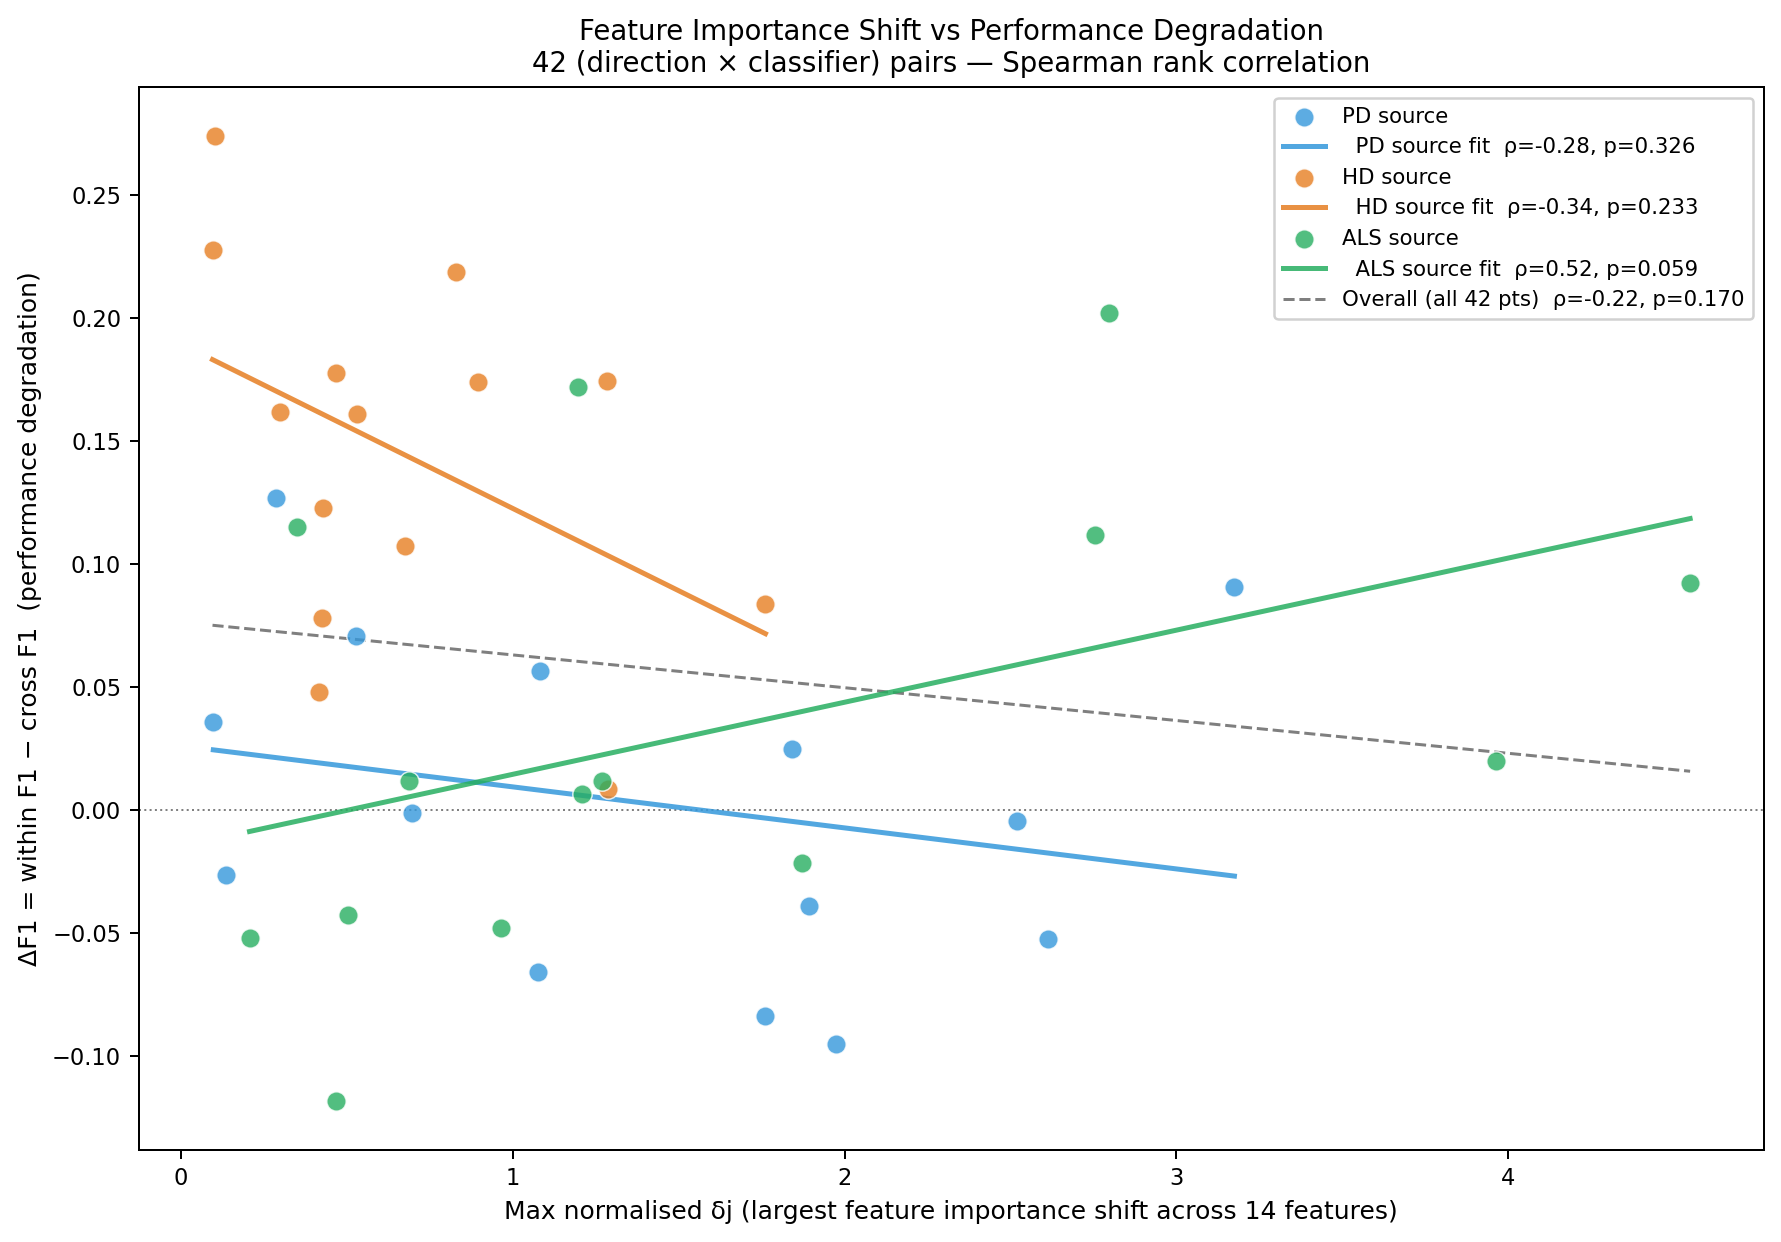

Overall Spearman ρ = -0.216,  p = 0.1696
Overall Pearson  r = -0.146,  p = 0.3571

PD source: Spearman ρ=-0.284 p=0.326  |  Pearson r=-0.244 p=0.401  (n=14)
HD source: Spearman ρ=-0.341 p=0.233  |  Pearson r=-0.441 p=0.115  (n=14)
ALS source: Spearman ρ=0.516 p=0.059  |  Pearson r=0.436 p=0.119  (n=14)


In [28]:
COND_COLORS = {'pd': '#3498db', 'hd': '#e67e22', 'als': '#27ae60'}
COND_LABELS_SC = {'pd': 'PD source', 'hd': 'HD source', 'als': 'ALS source'}

records = []
for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    src = SOURCE_FROM_DIR[d]
    for ci, (clf, cl) in enumerate(zip(CLF_NAMES, CLF_LABELS)):
        top_dj_norm = float(delta_j_norm_matrix[:, di, ci].max())
        within_f1   = WITHIN_F1_PER_CLF[src][clf]
        cross_f1    = cc[d]['classifiers'][clf]['f1_macro']
        delta_f1    = within_f1 - cross_f1
        records.append({
            'direction': dl, 'classifier': cl, 'source': src,
            'top_dj_norm': top_dj_norm, 'delta_f1': delta_f1,
        })

df_scatter = pd.DataFrame(records)

scatter_x_all = df_scatter['top_dj_norm'].values
scatter_y_all = df_scatter['delta_f1'].values

rho_overall, p_overall = stats.spearmanr(scatter_x_all, scatter_y_all)
r_pearson, p_pearson   = stats.pearsonr(scatter_x_all, scatter_y_all)

fig, ax = plt.subplots(figsize=(10, 7))

for src_cond in ['pd', 'hd', 'als']:
    mask = df_scatter['source'] == src_cond
    sx = df_scatter.loc[mask, 'top_dj_norm'].values
    sy = df_scatter.loc[mask, 'delta_f1'].values

    ax.scatter(sx, sy, c=COND_COLORS[src_cond], label=COND_LABELS_SC[src_cond],
               s=60, alpha=0.80, edgecolors='white', linewidths=0.6, zorder=3)

    if len(sx) > 2:
        slope, intercept = np.polyfit(sx, sy, 1)
        rho_cond, p_cond = stats.spearmanr(sx, sy)
        x_line = np.linspace(sx.min(), sx.max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=COND_COLORS[src_cond], linewidth=2.0,
                linestyle='-', alpha=0.85, zorder=2,
                label=f'  {COND_LABELS_SC[src_cond]} fit  ρ={rho_cond:.2f}, p={p_cond:.3f}')

# Overall reference line (secondary, dashed)
x_line_all = np.linspace(scatter_x_all.min(), scatter_x_all.max(), 100)
slope_all, intercept_all = np.polyfit(scatter_x_all, scatter_y_all, 1)
ax.plot(x_line_all, slope_all * x_line_all + intercept_all,
        color='black', linewidth=1.2, linestyle='--', alpha=0.5, zorder=1,
        label=f'Overall (all 42 pts)  ρ={rho_overall:.2f}, p={p_overall:.3f}')

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':', zorder=0)
ax.set_xlabel('Max normalised δj (largest feature importance shift across 14 features)', fontsize=10)
ax.set_ylabel('ΔF1 = within F1 − cross F1  (performance degradation)', fontsize=10)
ax.set_title(
    'Feature Importance Shift vs Performance Degradation\n'
    '42 (direction × classifier) pairs — Spearman rank correlation',
    fontsize=11,
)
ax.legend(fontsize=8.5, framealpha=0.9)
fig.tight_layout()

fig.savefig(FIGURES_PDF / f'delta_j_vs_degradation.pdf')
fig.savefig(FIGURES_PNG / f'delta_j_vs_degradation.png')
plt.show()

print(f'Overall Spearman ρ = {rho_overall:.3f},  p = {p_overall:.4f}')
print(f'Overall Pearson  r = {r_pearson:.3f},  p = {p_pearson:.4f}')
print()
for src_cond in ['pd', 'hd', 'als']:
    mask = df_scatter['source'] == src_cond
    sx = df_scatter.loc[mask, 'top_dj_norm'].values
    sy = df_scatter.loc[mask, 'delta_f1'].values
    rho_c, p_c   = stats.spearmanr(sx, sy)
    r_c,   p_c2  = stats.pearsonr(sx, sy)
    print(f'{COND_LABELS_SC[src_cond]}: Spearman ρ={rho_c:.3f} p={p_c:.3f}  |  '
          f'Pearson r={r_c:.3f} p={p_c2:.3f}  (n={len(sx)})')

### Cell 7c — RF Subject-Level δj vs Subject Accuracy

This RF-first analysis validates the pool-level δj idea at the patient level. For each transfer direction, a subject-specific cross-condition SHAP profile is compared against the RF within-condition template from the source pool. The weighted subject-shift score is then correlated with that subject's classification accuracy.

**Shift score definition:** `Σ within_mean_abs[j] × |subject_cross_mean_abs[j] − within_mean_abs[j]| / Σ within_mean_abs[j]`

**What to look for:** A negative Spearman correlation means subjects with larger RF feature-importance shifts tend to have lower stride-level accuracy, directly supporting δj as a transfer-failure diagnostic rather than just a pool-level summary.


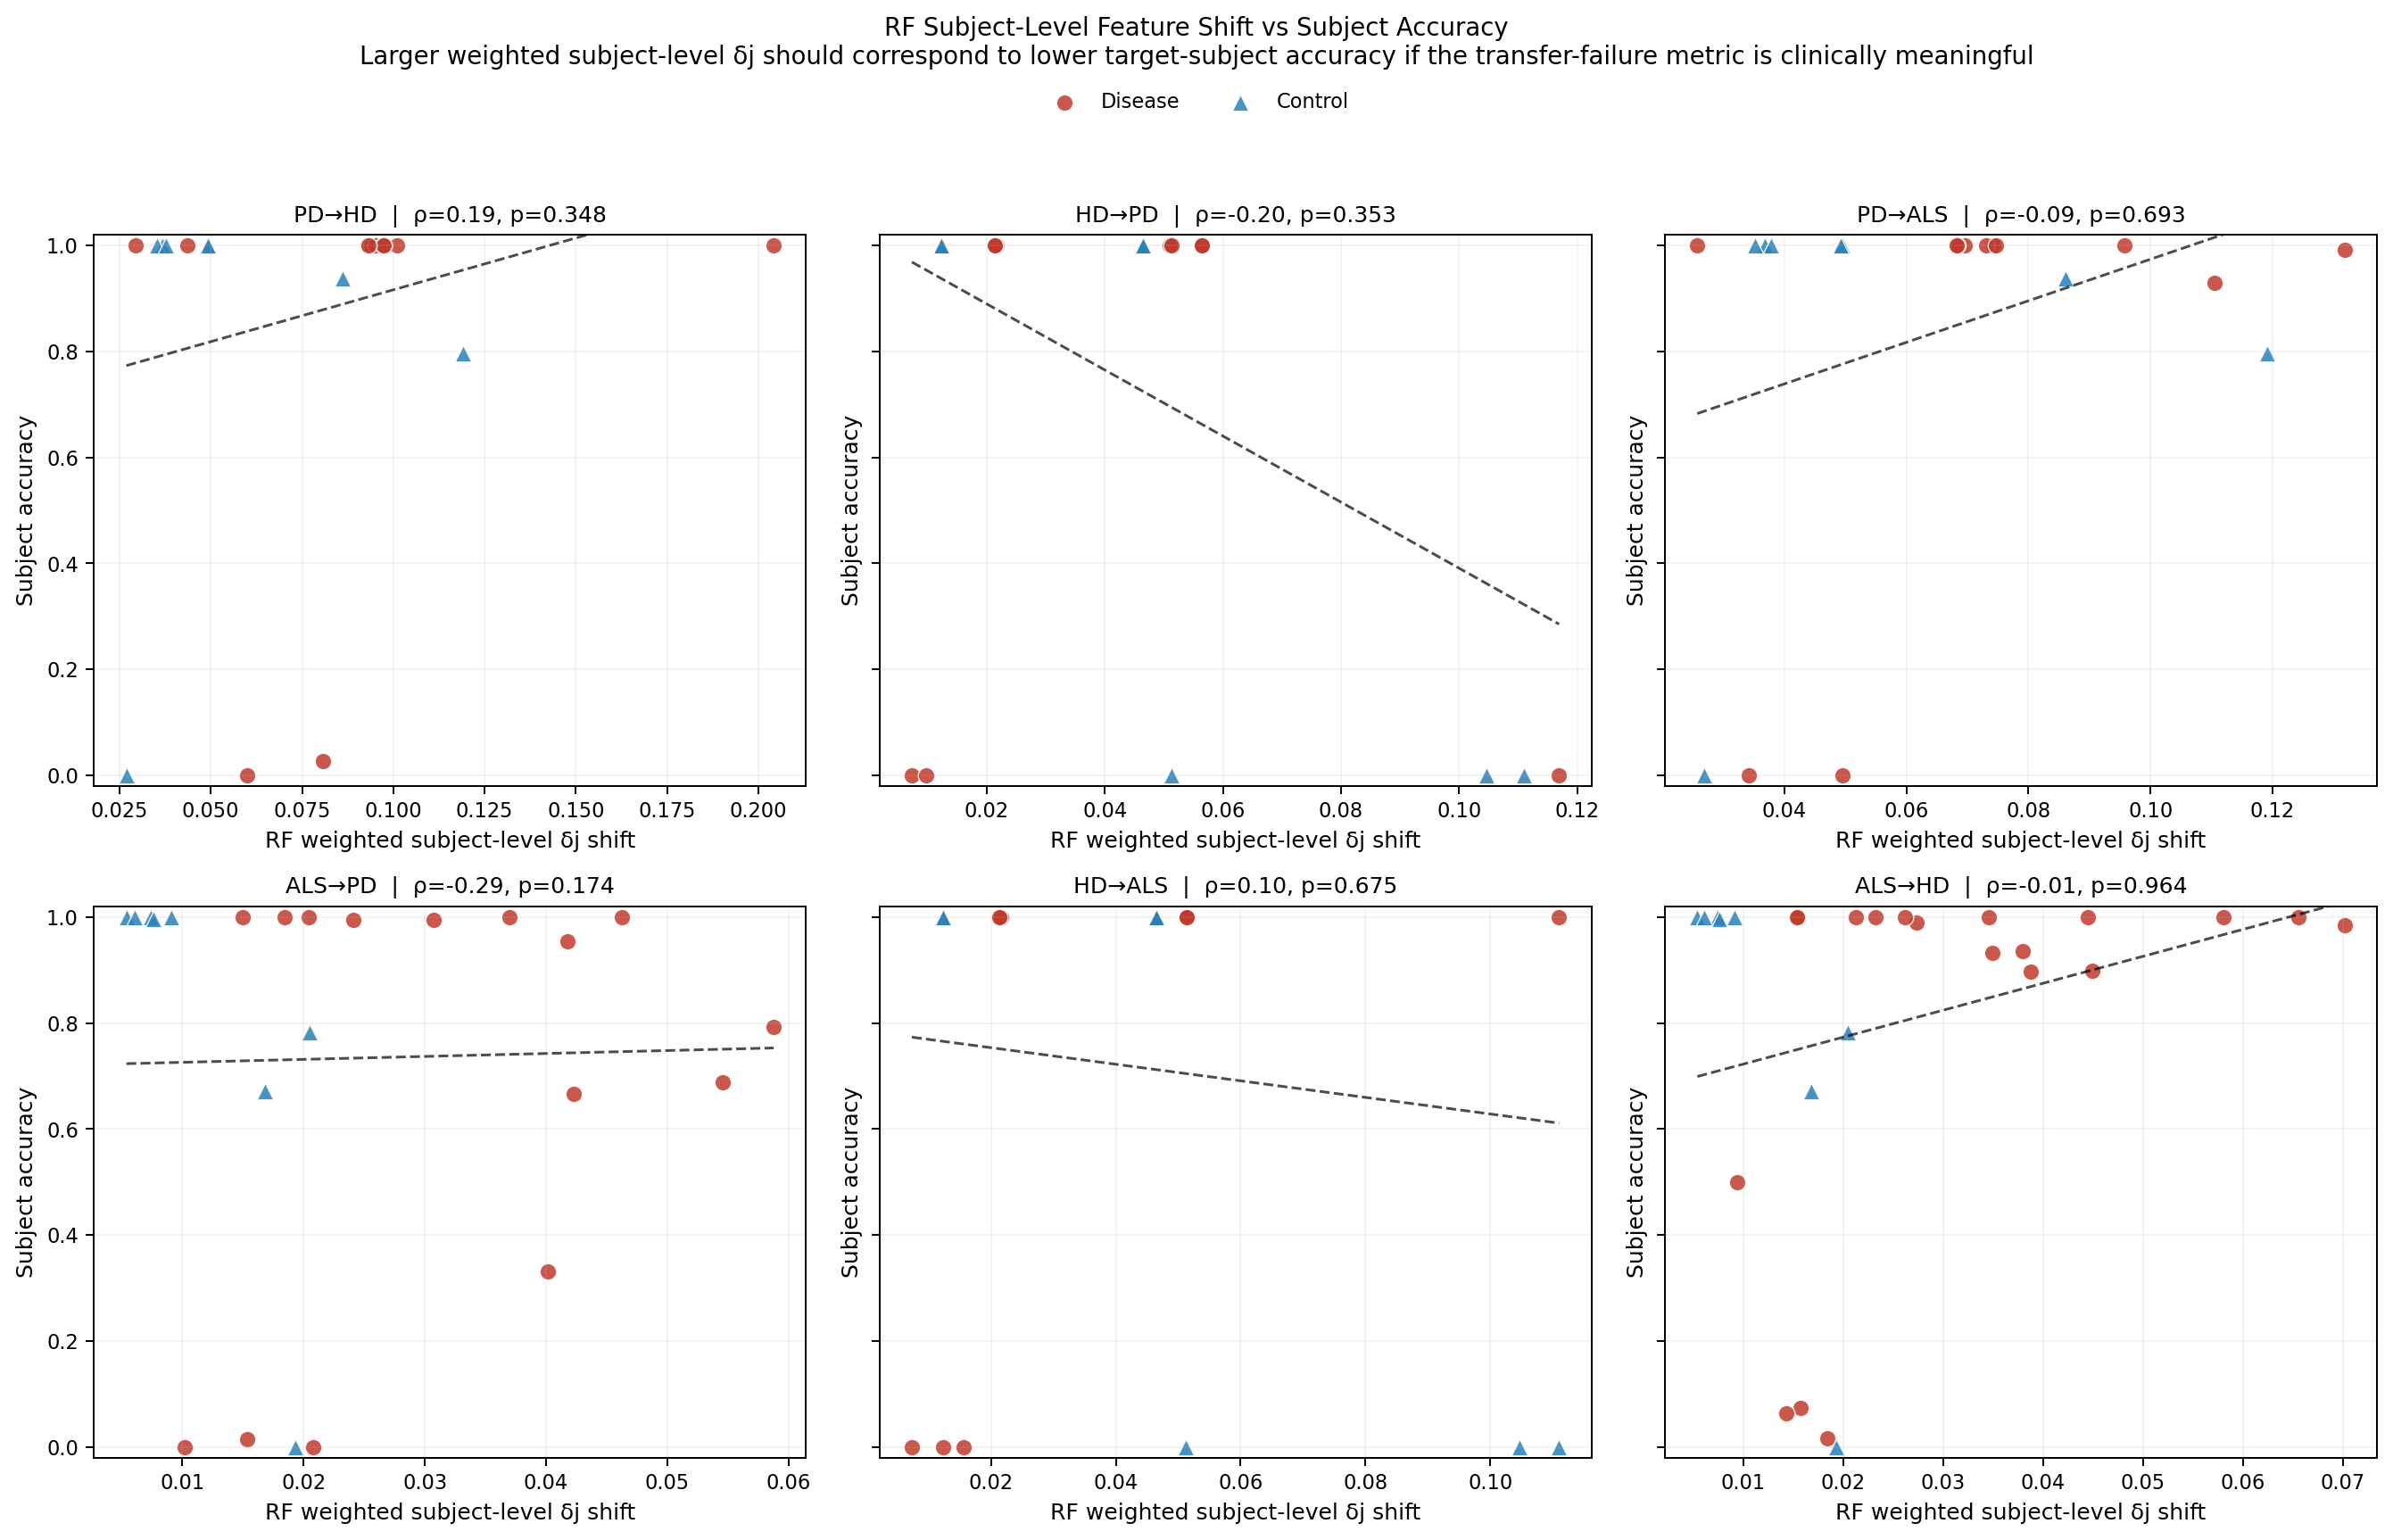

,Direction,Spearman ρ,p-value,n subjects
0,PD→HD,+0.188,0.3481,27
1,HD→PD,-0.203,0.3527,23
2,PD→ALS,-0.091,0.6934,21
3,ALS→PD,-0.294,0.1737,23
4,HD→ALS,+0.097,0.6752,21
5,ALS→HD,-0.009,0.9642,27


,direction,source,target,subject_id,label,weighted_shift,max_shift,accuracy
0,PD→HD,pd,hd,control10,Control,0.036814,0.089582,1.000000
1,PD→HD,pd,hd,control11,Control,0.035283,0.070780,1.000000
2,PD→HD,pd,hd,control12,Control,0.086058,0.101206,0.938525
3,PD→HD,pd,hd,control13,Control,0.037827,0.087793,1.000000
4,PD→HD,pd,hd,control14,Control,0.049493,0.078004,1.000000
5,PD→HD,pd,hd,control15,Control,0.026897,0.084757,0.000000
6,PD→HD,pd,hd,control16,Control,0.119140,0.140733,0.796000
7,PD→HD,pd,hd,control9,Control,0.049294,0.076997,1.000000
8,PD→HD,pd,hd,hunt1,Disease,0.101002,0.128962,1.000000
9,PD→HD,pd,hd,hunt10,Disease,0.095768,0.121940,1.000000


Saved rf_subject_delta_vs_accuracyv2.pdf / .png


In [29]:
# ── Cell 7c: RF subject-level δj vs subject accuracy ───────────────────────────
rf_subject_rows = []
rf_within_template_cache = {}

for direction, dir_label in zip(DIRECTIONS, DIR_LABELS):
    src, tgt = direction.split('_to_')

    if src not in rf_within_template_cache:
        within_npz = np.load(SHAP_DIR / f'{src}_rf_within.npz')
        rf_within_template_cache[src] = np.mean(
            np.abs(within_npz['shap_values'].astype(np.float64)),
            axis=0,
        )

    within_template = rf_within_template_cache[src]
    cross_npz = np.load(SHAP_DIR / f'{src}_rf_cross_{tgt}.npz')
    cross_shap = cross_npz['shap_values'].astype(np.float64)

    y_true = np.array(cc[direction]['classifiers']['rf']['y_true'])
    y_pred = np.array(cc[direction]['classifiers']['rf']['y_pred'])
    subject_ids = np.array(cc[direction]['target_subject_ids'])

    assert len(subject_ids) == len(y_true) == len(y_pred) == len(cross_shap), (
        f'RF alignment mismatch for {direction}'
    )

    for subject_id in dict.fromkeys(subject_ids.tolist()):
        mask = subject_ids == subject_id
        subject_profile = np.mean(np.abs(cross_shap[mask]), axis=0)
        subject_delta = np.abs(subject_profile - within_template)
        weighted_shift = float(np.sum(subject_delta * within_template) / np.sum(within_template))
        max_shift = float(subject_delta.max())
        accuracy = float(np.mean(y_true[mask] == y_pred[mask]))
        label = 'Disease' if y_true[mask][0] == 1 else 'Control'
        rf_subject_rows.append({
            'direction': dir_label,
            'source': src,
            'target': tgt,
            'subject_id': subject_id,
            'label': label,
            'weighted_shift': weighted_shift,
            'max_shift': max_shift,
            'accuracy': accuracy,
        })

df_rf_subject = pd.DataFrame(rf_subject_rows)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False, sharey=True)
axes_flat = axes.ravel()
corr_rows = []

for ax, dir_label in zip(axes_flat, DIR_LABELS):
    sub = df_rf_subject[df_rf_subject['direction'] == dir_label].copy()
    rho, p = stats.spearmanr(sub['weighted_shift'], sub['accuracy'])
    corr_rows.append({'Direction': dir_label, 'Spearman ρ': rho, 'p-value': p, 'n subjects': len(sub)})

    for label, color, marker in [('Disease', '#c0392b', 'o'), ('Control', '#2980b9', '^')]:
        sub_l = sub[sub['label'] == label]
        ax.scatter(
            sub_l['weighted_shift'], sub_l['accuracy'],
            c=color, marker=marker, s=55, alpha=0.85,
            edgecolors='white', linewidths=0.6,
            label=label if dir_label == DIR_LABELS[0] else None,
        )

    if len(sub) >= 3:
        slope, intercept = np.polyfit(sub['weighted_shift'], sub['accuracy'], 1)
        x_line = np.linspace(sub['weighted_shift'].min(), sub['weighted_shift'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

    ax.set_title(f'{dir_label}  |  ρ={rho:.2f}, p={p:.3f}', fontsize=10)
    ax.set_xlabel('RF weighted subject-level δj shift')
    ax.set_ylabel('Subject accuracy')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.20, linewidth=0.6)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    'RF Subject-Level Feature Shift vs Subject Accuracy\n'
    'Larger weighted subject-level δj should correspond to lower target-subject accuracy if the transfer-failure metric is clinically meaningful',
    fontsize=11, y=1.06,
)
fig.tight_layout()
fig_suffix = 'v2' if 'v2' else ''
fig.savefig(FIGURES_PDF / f'rf_subject_delta_vs_accuracy.pdf')
fig.savefig(FIGURES_PNG / f'rf_subject_delta_vs_accuracy.png')
plt.show()

df_rf_subject_corr = pd.DataFrame(corr_rows)
display(df_rf_subject_corr.style.format({'Spearman ρ': '{:+.3f}', 'p-value': '{:.4f}'}))
display(df_rf_subject.head(12))
print(f"Saved rf_subject_delta_vs_accuracy{fig_suffix}.pdf / .png")


### Cell 8 — Waterfall Plots for Selected Misclassified Cases (RF, pd→hd)

Loads `experiments/shap/v2/pd_rf_cross_hd.npz` and identifies the 3 strides where the PD-trained RF model was most confidently wrong when applied to HD data — predicted class ≠ true class, with predicted probability furthest from 0.5.

Each waterfall plot shows how individual feature values pushed the prediction away from the base value towards the final prediction. Features that push right (red) increase the predicted probability of disease; features that push left (blue) decrease it.


Total strides in pd_rf_cross_hd.npz: 6611
Misclassified strides: 761 (11.5%)


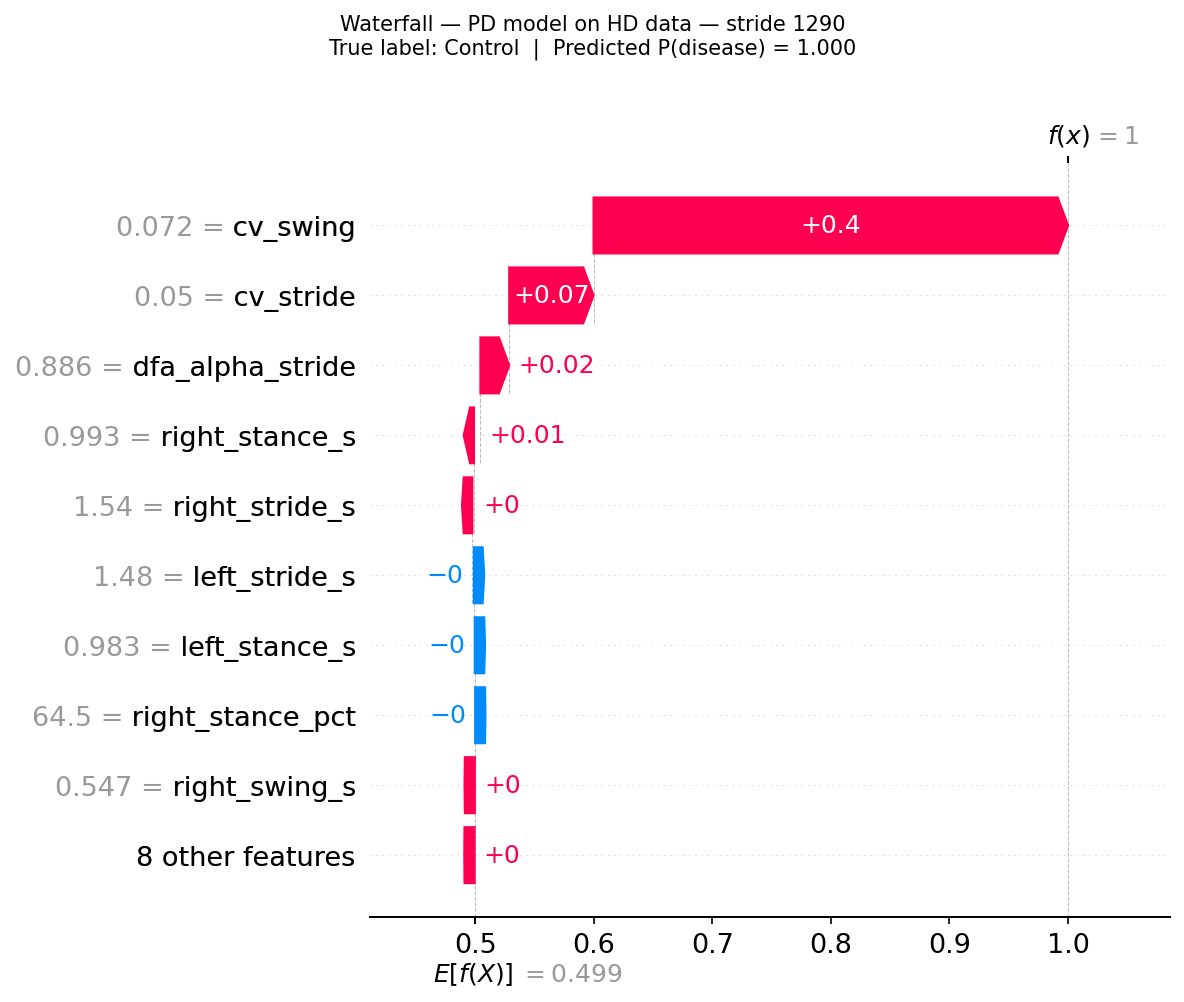

Case 1: stride 1290 | True: Control | P(disease)=1.000


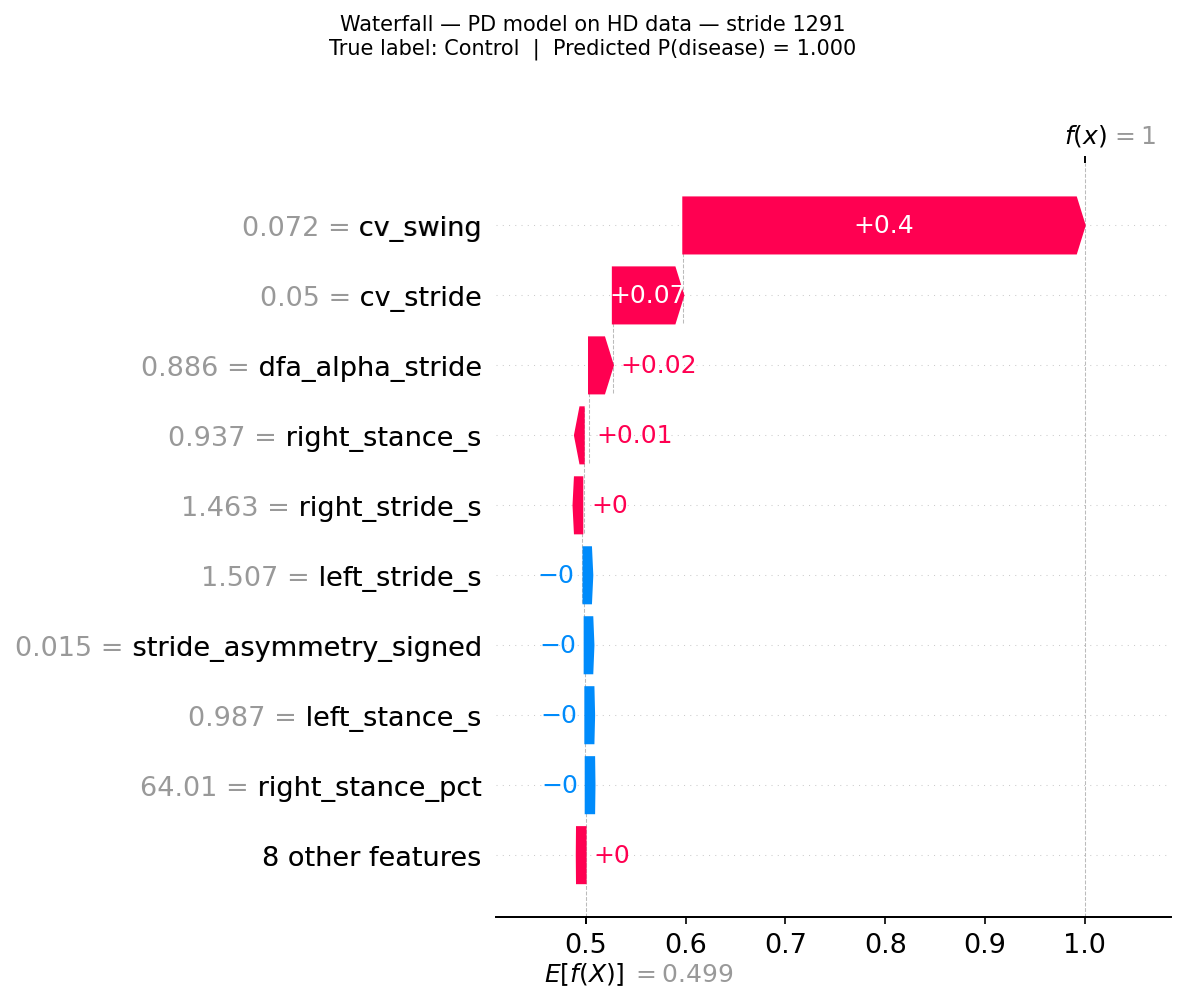

Case 2: stride 1291 | True: Control | P(disease)=1.000


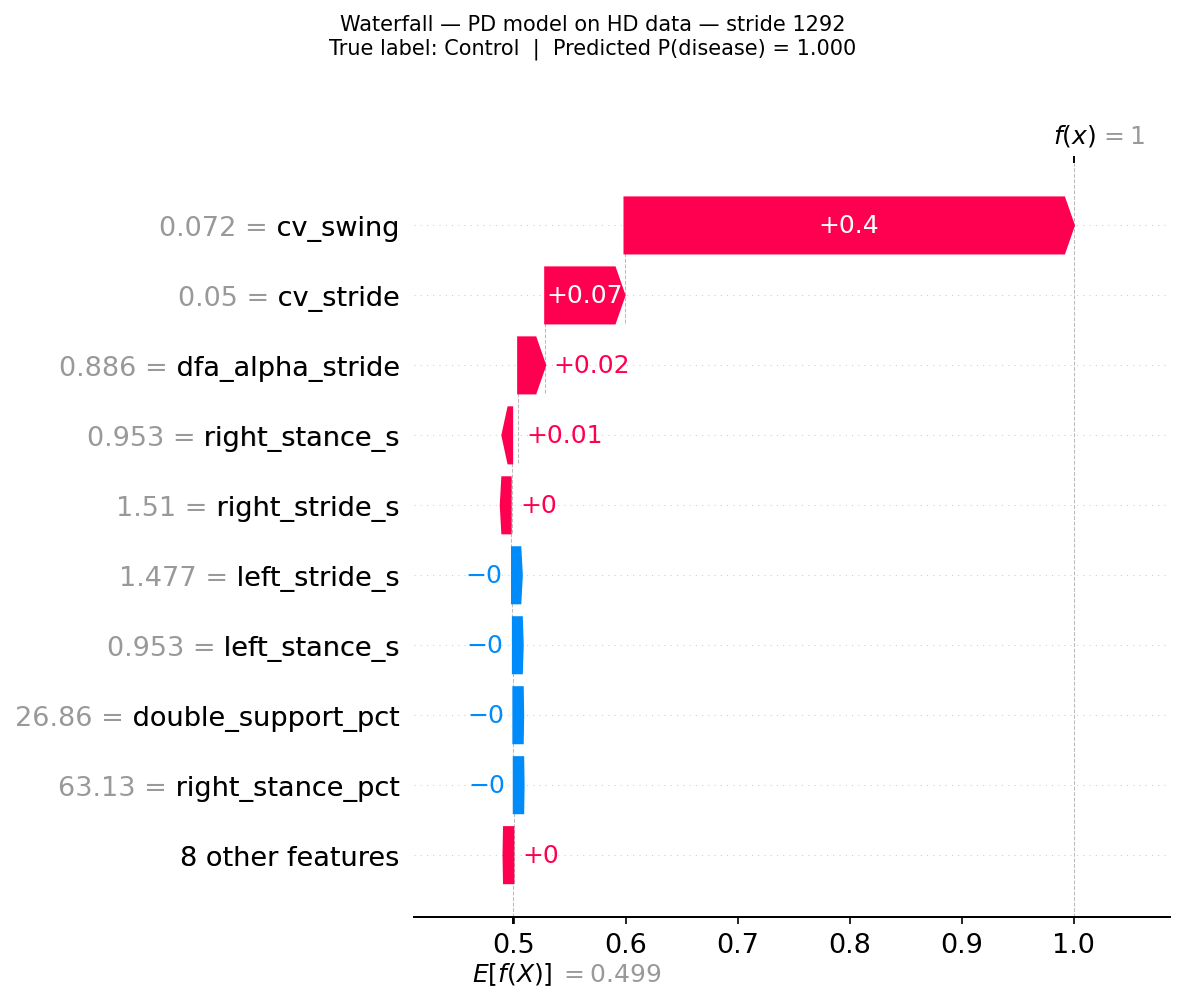

Case 3: stride 1292 | True: Control | P(disease)=1.000

Saved 3 waterfall plots to report/figures/v2/pdf/ and report/figures/v2/png/


In [30]:
npz_path = SHAP_DIR / 'pd_rf_cross_hd.npz'
npz = np.load(npz_path)

shap_vals_npz = npz['shap_values'].astype(np.float64)
base_val_npz = float(npz['base_value'])
X_expl_npz = npz['X_explained'].astype(np.float64)
y_true_npz = npz['y_true']

pipeline_rf = joblib.load(MODELS_DIR / 'pd_rf.joblib')
predicted_proba = pipeline_rf.predict_proba(X_expl_npz)[:, 1]
predicted_class = (predicted_proba > 0.5).astype(int)

misclassified = np.where(predicted_class != y_true_npz)[0]
print(f'Total strides in pd_rf_cross_hd.npz: {len(y_true_npz)}')
print(f'Misclassified strides: {len(misclassified)} ({100*len(misclassified)/len(y_true_npz):.1f}%)')

if len(misclassified) == 0:
    print('No misclassified strides — waterfall plots skipped.')
else:
    confidence = np.abs(predicted_proba[misclassified] - 0.5)
    top_k = min(3, len(misclassified))
    top_idx = misclassified[np.argsort(confidence)[::-1][:top_k]]

    for i, stride_idx in enumerate(top_idx):
        explanation = shap.Explanation(
            values=shap_vals_npz[stride_idx],
            base_values=base_val_npz,
            data=X_expl_npz[stride_idx],
            feature_names=FEATURE_COLS,
        )

        shap.plots.waterfall(explanation, show=False)
        fig_w = plt.gcf()

        true_label = 'Control' if y_true_npz[stride_idx] == 0 else 'HD patient'
        pred_prob = predicted_proba[stride_idx]
        fig_w.suptitle(
            f'Waterfall — PD model on HD data — stride {stride_idx}\n'
            f'True label: {true_label}  |  Predicted P(disease) = {pred_prob:.3f}',
            fontsize=10,
            y=1.02,
        )
        fig_w.tight_layout()

        fig_w.savefig(FIGURES_PDF / f'waterfall_pd_to_hd_case_{i+1}.pdf', bbox_inches='tight')
        fig_w.savefig(FIGURES_PNG / f'waterfall_pd_to_hd_case_{i+1}.png', dpi=300, bbox_inches='tight')

        buf = io.BytesIO()
        fig_w.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        plt.close(fig_w)
        display(IPyImage(data=buf.read()))
        print(f'Case {i+1}: stride {stride_idx} | True: {true_label} | P(disease)={pred_prob:.3f}')

    print(f'\nSaved {top_k} waterfall plots to report/figures/v2/pdf/ and report/figures/v2/png/')


## Clinical Interpretation of δj Results

The authoritative v2 SHAP results should be interpreted at the level of **feature families and directional asymmetry**, not as proof that every single top-ranked timing feature is uniquely causal. The timing block is correlated, so SHAP can redistribute attribution within that family while the broader transfer-failure pattern remains stable.

Two points matter most for the paper:

1. **`cv_swing` is the dominant transfer-failure feature in the authoritative v2 SHAP summary.** Averaged across all directions and classifiers, its mean `δj` is `0.0415`, well ahead of `cv_stride` (`0.0172`); at the RF level it is rank-1 in 5 of the 6 directions.
2. **`dfa_alpha_stride` deserves its own directionality figure because the effect is asymmetric.** Its RF `δj` is high in the PD-source directions (`pd_to_hd = 0.0305`, `pd_to_als = 0.0416`) but near-zero in the HD-source direction `hd_to_als` (`0.0002`), so the signal is not simply “HD-source dominant.”

That framing keeps the notebook aligned with the scientific caution we now want in the manuscript: the main Step 4 result is about which gait mechanisms shift under transfer, with `cv_swing` as the leading variability feature and `dfa_alpha_stride` as a selective directional signal.
